# Ball-in-Air Separation Delta (BIAS) Analysis

This notebook analyzes how the separation between the target receiver and nearest defender changes while the ball is in flight.

**BIAS Metric:**
```
BIAS = Separation_catch - Separation_release
```

**Key Questions:**
- How does separation change from ball release to catch?
- Which route concepts increase separation the most?
- How does coverage type affect BIAS?
- Does throw depth impact separation changes?

**Defenders Analyzed:**
- Cornerbacks (CB)
- Linebackers (LB) 
- Safeties (FS/SS)
- Whichever is nearest to the target receiver


In [1]:
# =========================
# Cell 1 — Imports & Config
# =========================
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Data paths
DATA_PATH = Path("../data/114239_nfl_competition_files_published_analytics_final")
TRAIN_DIR = DATA_PATH / "train"
SUPPLEMENTARY_PATH = DATA_PATH / "supplementary_data.csv"

print("✅ Imports and config loaded!")


✅ Imports and config loaded!


In [2]:
# =========================
# Cell 2 — Load All Data
# =========================
# Load all input files from all weeks
input_files = sorted(TRAIN_DIR.glob("input_*.csv"))
print(f"📂 Found {len(input_files)} input files")

# Load all tracking data
all_tracking = []
for file in input_files:
    df = pd.read_csv(file)
    all_tracking.append(df)
    print(f"  Loaded {file.name}: {df.shape[0]:,} rows")

tracking = pd.concat(all_tracking, ignore_index=True)
print(f"\n✅ Total tracking data: {tracking.shape[0]:,} rows")

# Load supplementary data (play information)
plays = pd.read_csv(SUPPLEMENTARY_PATH)
print(f"✅ Supplementary data: {plays.shape[0]:,} plays")

print(f"\n📊 Tracking columns: {list(tracking.columns)}")


📂 Found 18 input files
  Loaded input_2023_w01.csv: 285,714 rows
  Loaded input_2023_w02.csv: 288,586 rows
  Loaded input_2023_w03.csv: 297,757 rows
  Loaded input_2023_w04.csv: 272,475 rows
  Loaded input_2023_w05.csv: 254,779 rows
  Loaded input_2023_w06.csv: 270,676 rows
  Loaded input_2023_w07.csv: 233,597 rows
  Loaded input_2023_w08.csv: 281,011 rows
  Loaded input_2023_w09.csv: 252,796 rows
  Loaded input_2023_w10.csv: 260,372 rows
  Loaded input_2023_w11.csv: 243,413 rows
  Loaded input_2023_w12.csv: 294,940 rows
  Loaded input_2023_w13.csv: 233,755 rows
  Loaded input_2023_w14.csv: 279,972 rows
  Loaded input_2023_w15.csv: 281,820 rows
  Loaded input_2023_w16.csv: 316,417 rows
  Loaded input_2023_w17.csv: 277,582 rows
  Loaded input_2023_w18.csv: 254,917 rows

✅ Total tracking data: 4,880,579 rows
✅ Supplementary data: 18,009 plays

📊 Tracking columns: ['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id', 'play_direction', 'absolute_yardline_number', 'player_name',

/var/folders/7n/t_bt1q9s63n849ghblhw47hh0000gn/T/ipykernel_4870/4153423092.py:19: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  plays = pd.read_csv(SUPPLEMENTARY_PATH)


In [3]:
# =========================
# Cell 3 — Calculate Ball Release Frames
# =========================
def get_ball_release_frames(tracking_data):
    """
    Calculate ball release frame for each play.
    Formula: ball_release_frame = max(input_frame_id) - num_frames_output
    """
    play_info = tracking_data.groupby('play_id').agg({
        'frame_id': 'max',
        'num_frames_output': 'first'
    }).reset_index()
    
    play_info.columns = ['play_id', 'max_input_frame', 'num_output_frames']
    play_info['ball_release_frame'] = (
        play_info['max_input_frame'] - play_info['num_output_frames']
    )
    
    play_info = play_info[play_info['ball_release_frame'] >= 1]
    return play_info

# Calculate ball release frames
ball_release_info = get_ball_release_frames(tracking)

# Merge with tracking data
tracking = tracking.merge(
    ball_release_info[['play_id', 'ball_release_frame']], 
    on='play_id', 
    how='left'
)

print("🎯 Ball release frames calculated")
print(f"Total plays: {len(ball_release_info)}")
print(f"\nSample ball release frames:")
print(ball_release_info.head(10))


🎯 Ball release frames calculated
Total plays: 4289

Sample ball release frames:
   play_id  max_input_frame  num_output_frames  ball_release_frame
0       54               45                  7                  38
1       55               54                  9                  45
2       56               49                 10                  39
3       58               19                  7                  12
4       59               17                  9                   8
5       60               26                  6                  20
6       62               45                 11                  34
7       63               40                 10                  30
8       64               43                 10                  33
9       67               27                  7                  20


In [ ]:
# =========================
# Cell 4 — Identify Target Receivers and Defenders
# =========================
# Target receivers are players with player_to_predict = True on offense
target_receivers = tracking[
    (tracking['player_to_predict'] == True) & 
    (tracking['player_side'] == 'Offense')
].copy()

print(f"🎯 Target receivers: {len(target_receivers):,} frames")
print(f"   Unique target receivers: {target_receivers['nfl_id'].nunique()}")
print(f"   Unique plays: {target_receivers['play_id'].nunique()}")
print(f"\n   Position breakdown:")
print(target_receivers['player_position'].value_counts())

# Defenders: CB, LB, FS, SS on defense
defenders = tracking[
    (tracking['player_position'].isin(['CB', 'LB', 'FS', 'SS'])) & 
    (tracking['player_side'] == 'Defense')
].copy()

print(f"\n🛡️ Defenders: {len(defenders):,} frames")
print(f"   Unique defenders: {defenders['nfl_id'].nunique()}")
print(f"   Position breakdown:")
print(defenders['player_position'].value_counts())


🎯 Target receivers: 396,914 frames
   Unique target receivers: 464
   Unique plays: 4317

🛡️ Defenders: 1,924,569 frames
   Unique defenders: 386
   Position breakdown:
player_position
CB    1055252
FS     476865
SS     392421
LB         31
Name: count, dtype: int64


In [5]:
# =========================
# Cell 5 — Calculate Separation at Each Frame
# =========================
def calculate_separation_at_frames(tracking_df, target_receivers_df, defenders_df):
    """
    For each target receiver at each frame, find the nearest defender and calculate separation.
    Returns a dataframe with separation metrics.
    """
    results = []
    
    # Group by play_id and frame_id for efficiency
    for play_id in target_receivers_df['play_id'].unique():
        play_targets = target_receivers_df[target_receivers_df['play_id'] == play_id]
        play_defenders = defenders_df[defenders_df['play_id'] == play_id]
        
        if len(play_targets) == 0 or len(play_defenders) == 0:
            continue
        
        # Get ball release frame for this play
        ball_release_frame = play_targets['ball_release_frame'].iloc[0]
        ball_land_x = play_targets['ball_land_x'].iloc[0]
        ball_land_y = play_targets['ball_land_y'].iloc[0]
        
        # For each target receiver in this play
        for target_nfl_id in play_targets['nfl_id'].unique():
            target_frames = play_targets[play_targets['nfl_id'] == target_nfl_id].sort_values('frame_id')
            
            for idx, target_row in target_frames.iterrows():
                frame_id = target_row['frame_id']
                target_x = target_row['x']
                target_y = target_row['y']
                
                # Get defenders at this same frame
                defenders_at_frame = play_defenders[play_defenders['frame_id'] == frame_id]
                
                if len(defenders_at_frame) == 0:
                    continue
                
                # Calculate distance to each defender
                defenders_at_frame = defenders_at_frame.copy()
                defenders_at_frame['distance'] = np.sqrt(
                    (defenders_at_frame['x'] - target_x)**2 + 
                    (defenders_at_frame['y'] - target_y)**2
                )
                
                # Find nearest defender
                nearest_defender = defenders_at_frame.loc[defenders_at_frame['distance'].idxmin()]
                
                separation = nearest_defender['distance']
                
                results.append({
                    'game_id': target_row['game_id'],
                    'play_id': play_id,
                    'frame_id': frame_id,
                    'target_nfl_id': target_nfl_id,
                    'target_name': target_row['player_name'],
                    'target_position': target_row['player_position'],
                    'nearest_defender_nfl_id': nearest_defender['nfl_id'],
                    'nearest_defender_name': nearest_defender['player_name'],
                    'nearest_defender_position': nearest_defender['player_position'],
                    'separation': separation,
                    'ball_release_frame': ball_release_frame,
                    'frames_from_release': frame_id - ball_release_frame,
                    'ball_land_x': ball_land_x,
                    'ball_land_y': ball_land_y,
                })
    
    return pd.DataFrame(results)

print("🔧 Calculating separation at each frame...")
print("   This may take a few minutes...")

separation_data = calculate_separation_at_frames(tracking, target_receivers, defenders)

print(f"\n✅ Calculated separation for {len(separation_data):,} frame-receiver combinations")
print(f"\nSample results:")
print(separation_data.head(10))


🔧 Calculating separation at each frame...
   This may take a few minutes...

✅ Calculated separation for 396,914 frame-receiver combinations

Sample results:
      game_id  play_id  frame_id  target_nfl_id    target_name  \
0  2023090700      101         1          44930  Josh Reynolds   
1  2023090700      101         2          44930  Josh Reynolds   
2  2023090700      101         3          44930  Josh Reynolds   
3  2023090700      101         4          44930  Josh Reynolds   
4  2023090700      101         5          44930  Josh Reynolds   
5  2023090700      101         6          44930  Josh Reynolds   
6  2023090700      101         7          44930  Josh Reynolds   
7  2023090700      101         8          44930  Josh Reynolds   
8  2023090700      101         9          44930  Josh Reynolds   
9  2023090700      101        10          44930  Josh Reynolds   

  target_position  nearest_defender_nfl_id nearest_defender_name  \
0              WR                    52546     

In [ ]:
# =========================
# Cell 6.5 — Diagnostic: Examine Specific Plays for Ball Release Validation
# =========================
# This cell helps validate ball release frame calculations by examining specific plays

def diagnose_play(play_id_to_check, game_id_to_check=None):
    """
    Diagnose a specific play to validate ball release frame and BIAS calculation.
    """
    print("=" * 80)
    print(f"DIAGNOSTIC: Play {play_id_to_check}")
    print("=" * 80)
    
    # Get play data
    if game_id_to_check:
        play_separation = separation_data[
            (separation_data['play_id'] == play_id_to_check) & 
            (separation_data['game_id'] == game_id_to_check)
        ].copy()
    else:
        play_separation = separation_data[separation_data['play_id'] == play_id_to_check].copy()
        if len(play_separation) > 0:
            game_id_to_check = play_separation['game_id'].iloc[0]
    
    if len(play_separation) == 0:
        print(f"⚠️  Play {play_id_to_check} not found in separation_data")
        return
    
    # Get ball release info
    if game_id_to_check:
        play_ball_release = ball_release_info[ball_release_info['play_id'] == play_id_to_check]
    else:
        play_ball_release = ball_release_info[ball_release_info['play_id'] == play_id_to_check]
    
    if len(play_ball_release) > 0:
        max_frame = play_ball_release['max_input_frame'].iloc[0]
        num_output = play_ball_release['num_output_frames'].iloc[0]
        calculated_release = play_ball_release['ball_release_frame'].iloc[0]
        
        print(f"\n📊 Ball Release Frame Calculation:")
        print(f"   Max input frame: {max_frame}")
        print(f"   Num output frames: {num_output}")
        print(f"   Calculated release frame: {calculated_release} (Formula: {max_frame} - {num_output})")
        print(f"   Frames after release in input: {max_frame - calculated_release}")
    
    # Get BIAS data
    play_bias = bias_data[
        (bias_data['play_id'] == play_id_to_check) & 
        (bias_data['game_id'] == game_id_to_check)
    ] if game_id_to_check else bias_data[bias_data['play_id'] == play_id_to_check]
    
    if len(play_bias) > 0:
        print(f"\n📊 BIAS Calculation:")
        for idx, row in play_bias.iterrows():
            print(f"\n   Target: {row['target_name']} ({row['target_position']})")
            print(f"   Nearest Defender: {row.get('nearest_defender_position', 'N/A')}")
            print(f"   Separation at release: {row['separation_release']:.2f} yards")
            print(f"   Separation at catch: {row['separation_catch']:.2f} yards")
            print(f"   BIAS: {row['bias']:.2f} yards")
            print(f"   Frames in air: {row['frames_in_air']}")
    
    # Show separation over time around ball release
    play_separation = play_separation.sort_values('frame_id')
    ball_release_frame = play_separation['ball_release_frame'].iloc[0]
    catch_frame = play_separation['frame_id'].max()
    
    print(f"\n📊 Separation Over Time (around ball release):")
    print(f"   Ball release frame: {ball_release_frame}")
    print(f"   Catch frame: {catch_frame}")
    
    # Show frames around release
    frames_to_show = play_separation[
        (play_separation['frame_id'] >= ball_release_frame - 5) & 
        (play_separation['frame_id'] <= ball_release_frame + 10)
    ].copy()
    
    if len(frames_to_show) > 0:
        print(f"\n   Frame | Separation | Defender Name | Defender Position | Frames from Release")
        print(f"   " + "-" * 75)
        for idx, row in frames_to_show.iterrows():
            frames_from_rel = row['frame_id'] - ball_release_frame
            marker = " <-- RELEASE" if frames_from_rel == 0 else ""
            print(f"   {row['frame_id']:5d} | {row['separation']:10.2f} | {row.get('nearest_defender_name', 'N/A'):15s} | {row.get('nearest_defender_position', 'N/A'):18s} | {frames_from_rel:3d}{marker}")
    
    # Check if nearest defender changes
    unique_defenders = play_separation.groupby('frame_id').agg({
        'nearest_defender_nfl_id': 'first',
        'nearest_defender_name': 'first'
    }).reset_index()
    
    defender_changes = unique_defenders['nearest_defender_nfl_id'].nunique()
    if defender_changes > 1:
        print(f"\n⚠️  Nearest defender changes during the play!")
        print(f"   {defender_changes} different defenders were nearest at different frames")
        print(f"   Defenders involved:")
        for def_id, def_name in unique_defenders[['nearest_defender_nfl_id', 'nearest_defender_name']].drop_duplicates().values:
            frames_as_nearest = len(unique_defenders[unique_defenders['nearest_defender_nfl_id'] == def_id])
            print(f"      {def_name} (nfl_id: {def_id}): nearest for {frames_as_nearest} frames")
    else:
        def_name = unique_defenders['nearest_defender_name'].iloc[0]
        print(f"\n✅ Same defender nearest throughout: {def_name}")
    
    # Get play description
    if 'plays' in locals():
        play_info = plays[
            (plays['play_id'] == play_id_to_check) & 
            (plays['game_id'] == game_id_to_check)
        ] if game_id_to_check else plays[plays['play_id'] == play_id_to_check]
        
        if len(play_info) > 0:
            print(f"\n📋 Play Description:")
            print(f"   {play_info['play_description'].iloc[0]}")
            print(f"   Pass Result: {play_info['pass_result'].iloc[0]}")
            print(f"   Pass Length: {play_info['pass_length'].iloc[0]:.1f} yards")
            if 'team_coverage_type' in play_info.columns:
                print(f"   Coverage: {play_info['team_coverage_type'].iloc[0]}")

# Example: Diagnose Play 3290 (the one you mentioned)
print("Examining Play 3290 (the play you mentioned):\n")
diagnose_play(3290)

print("\n\n" + "=" * 80)
print("You can diagnose other plays by calling: diagnose_play(play_id)")
print("=" * 80)


In [6]:
# =========================
# Cell 6 — Identify Catch Frame and Calculate BIAS
# =========================
# The catch frame is typically the last frame in the input data (max frame_id for each play)
# Or we can use the ball landing point as a proxy - the frame closest to ball landing

def calculate_bias(separation_df):
    """
    Calculate BIAS = Separation_catch - Separation_release
    For each play-target combination.
    """
    results = []
    
    for (play_id, target_nfl_id), play_data in separation_df.groupby(['play_id', 'target_nfl_id']):
        play_data = play_data.sort_values('frame_id').reset_index(drop=True)
        
        if len(play_data) == 0:
            continue
        
        ball_release_frame = play_data['ball_release_frame'].iloc[0]
        
        # Separation at release (frame at or just after ball release)
        release_frames = play_data[
            (play_data['frame_id'] >= ball_release_frame) & 
            (play_data['frame_id'] <= ball_release_frame + 2)
        ]
        
        if len(release_frames) == 0:
            continue
        
        separation_release = release_frames['separation'].iloc[0]  # Use first frame at/after release
        
        # Separation at catch (last frame in input data, which is closest to catch)
        # The max frame_id represents the end of input data, closest to catch
        catch_frame = play_data['frame_id'].max()
        catch_frames = play_data[play_data['frame_id'] == catch_frame]
        
        if len(catch_frames) == 0:
            continue
        
        separation_catch = catch_frames['separation'].iloc[0]
        
        # Calculate BIAS
        bias = separation_catch - separation_release
        
        # Additional metrics
        frames_in_air = catch_frame - ball_release_frame
        
        # Average separation during ball flight
        in_air_frames = play_data[
            (play_data['frame_id'] > ball_release_frame) & 
            (play_data['frame_id'] <= catch_frame)
        ]
        avg_separation_in_air = in_air_frames['separation'].mean() if len(in_air_frames) > 0 else None
        
        results.append({
            'game_id': play_data['game_id'].iloc[0],
            'play_id': play_id,
            'target_nfl_id': target_nfl_id,
            'target_name': play_data['target_name'].iloc[0],
            'target_position': play_data['target_position'].iloc[0],
            'nearest_defender_position': play_data['nearest_defender_position'].iloc[0],
            'ball_release_frame': ball_release_frame,
            'catch_frame': catch_frame,
            'frames_in_air': frames_in_air,
            'separation_release': separation_release,
            'separation_catch': separation_catch,
            'bias': bias,
            'avg_separation_in_air': avg_separation_in_air if avg_separation_in_air is not None else np.nan,
        })
    
    return pd.DataFrame(results)

print("🔧 Calculating BIAS for each play...")
bias_data = calculate_bias(separation_data)

print(f"\n✅ Calculated BIAS for {len(bias_data)} plays")
print(f"\nSample results:")
print(bias_data[['play_id', 'target_name', 'nearest_defender_position', 
                 'separation_release', 'separation_catch', 'bias']].head(10))

print(f"\n📊 BIAS Statistics:")
print(f"   Mean: {bias_data['bias'].mean():.4f} yards")
print(f"   Median: {bias_data['bias'].median():.4f} yards")
print(f"   Std: {bias_data['bias'].std():.4f} yards")
print(f"   Min: {bias_data['bias'].min():.4f} yards")
print(f"   Max: {bias_data['bias'].max():.4f} yards")


🔧 Calculating BIAS for each play...

✅ Calculated BIAS for 8973 plays

Sample results:
   play_id      target_name nearest_defender_position  separation_release  \
0       54   Rashod Bateman                        CB            2.534758   
1       55   Darius Slayton                        CB           11.768726   
2       55    D'Andre Swift                        FS           14.492508   
3       56   Darnell Mooney                        SS            1.618394   
4       56        Noah Gray                        CB            9.346764   
5       58     Stefon Diggs                        CB            1.164818   
6       59     Stefon Diggs                        SS            4.420916   
7       60  Michael Pittman                        FS            5.453192   
8       62    Juwan Johnson                        SS            2.805299   
9       62      Jerome Ford                        SS            9.902616   

   separation_catch      bias  
0          2.501540 -0.033219  
1

In [7]:
# =========================
# Cell 7 — Merge with Play Data for Coverage Type and Throw Depth
# =========================
# Merge with supplementary data to get coverage type and pass length
plays_subset = plays[[
    'game_id', 'play_id', 'pass_result', 'pass_length', 
    'team_coverage_type', 'team_coverage_man_zone'
]].copy()

bias_analysis = bias_data.merge(
    plays_subset,
    on=['game_id', 'play_id'],
    how='left'
)

# Filter to only completed passes (for meaningful BIAS analysis)
bias_analysis = bias_analysis[
    bias_analysis['pass_result'] == 'C'
].copy()

# Create throw depth categories
bias_analysis['throw_depth'] = pd.cut(
    bias_analysis['pass_length'],
    bins=[-np.inf, 5, 15, np.inf],
    labels=['Short (0-5 yds)', 'Medium (5-15 yds)', 'Deep (15+ yds)']
)

print(f"📊 BIAS Analysis Data: {len(bias_analysis)} completed passes")
print(f"\nCoverage Type Breakdown:")
print(bias_analysis['team_coverage_type'].value_counts())

print(f"\nThrow Depth Breakdown:")
print(bias_analysis['throw_depth'].value_counts())

print(f"\nNearest Defender Position Breakdown:")
print(bias_analysis['nearest_defender_position'].value_counts())


📊 BIAS Analysis Data: 6025 completed passes

Coverage Type Breakdown:
team_coverage_type
COVER_3_ZONE    1995
COVER_1_MAN     1144
COVER_4_ZONE    1041
COVER_2_ZONE     918
COVER_6_ZONE     633
COVER_0_MAN      185
COVER_2_MAN       86
PREVENT           22
Name: count, dtype: int64

Throw Depth Breakdown:
throw_depth
Short (0-5 yds)      3023
Medium (5-15 yds)    1963
Deep (15+ yds)       1039
Name: count, dtype: int64

Nearest Defender Position Breakdown:
nearest_defender_position
CB    3855
FS    1158
SS    1012
Name: count, dtype: int64


In [8]:
# =========================
# Cell 8 — BIAS Analysis by Coverage Type
# =========================
print("=" * 80)
print("BIAS ANALYSIS BY COVERAGE TYPE")
print("=" * 80)

coverage_types = bias_analysis['team_coverage_type'].dropna().unique()

coverage_stats = []
for coverage in sorted(coverage_types):
    coverage_data = bias_analysis[bias_analysis['team_coverage_type'] == coverage]
    
    if len(coverage_data) == 0:
        continue
    
    mean_bias = coverage_data['bias'].mean()
    median_bias = coverage_data['bias'].median()
    std_bias = coverage_data['bias'].std()
    n = len(coverage_data)
    
    coverage_stats.append({
        'coverage_type': coverage,
        'mean_bias': mean_bias,
        'median_bias': median_bias,
        'std_bias': std_bias,
        'n_plays': n
    })
    
    print(f"\n📊 {coverage}:")
    print(f"   Mean BIAS: {mean_bias:.4f} yards")
    print(f"   Median BIAS: {median_bias:.4f} yards")
    print(f"   Std Dev: {std_bias:.4f} yards")
    print(f"   Sample size: {n} plays")

coverage_df = pd.DataFrame(coverage_stats)
print(f"\n\n📋 Summary Table:")
print(coverage_df.to_string(index=False))

# Statistical tests between coverage types
if len(coverage_types) >= 2:
    print(f"\n\n🔬 Statistical Tests:")
    coverage_list = sorted(coverage_types)
    for i in range(len(coverage_list)):
        for j in range(i+1, len(coverage_list)):
            cov1 = coverage_list[i]
            cov2 = coverage_list[j]
            
            data1 = bias_analysis[bias_analysis['team_coverage_type'] == cov1]['bias'].dropna()
            data2 = bias_analysis[bias_analysis['team_coverage_type'] == cov2]['bias'].dropna()
            
            if len(data1) > 0 and len(data2) > 0:
                t_stat, p_val = stats.ttest_ind(data1, data2)
                print(f"   {cov1} vs {cov2}: p = {p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''}")


BIAS ANALYSIS BY COVERAGE TYPE

📊 COVER_0_MAN:
   Mean BIAS: -0.0689 yards
   Median BIAS: 0.0000 yards
   Std Dev: 2.1735 yards
   Sample size: 185 plays

📊 COVER_1_MAN:
   Mean BIAS: 0.2695 yards
   Median BIAS: 0.0348 yards
   Std Dev: 2.1545 yards
   Sample size: 1144 plays

📊 COVER_2_MAN:
   Mean BIAS: 1.3684 yards
   Median BIAS: 0.4600 yards
   Std Dev: 3.2073 yards
   Sample size: 86 plays

📊 COVER_2_ZONE:
   Mean BIAS: 1.0415 yards
   Median BIAS: 0.4852 yards
   Std Dev: 2.9117 yards
   Sample size: 918 plays

📊 COVER_3_ZONE:
   Mean BIAS: 0.6298 yards
   Median BIAS: 0.1256 yards
   Std Dev: 2.8656 yards
   Sample size: 1995 plays

📊 COVER_4_ZONE:
   Mean BIAS: 0.4042 yards
   Median BIAS: -0.0029 yards
   Std Dev: 2.7570 yards
   Sample size: 1041 plays

📊 COVER_6_ZONE:
   Mean BIAS: 0.9126 yards
   Median BIAS: 0.3361 yards
   Std Dev: 2.9227 yards
   Sample size: 633 plays

📊 PREVENT:
   Mean BIAS: 1.0586 yards
   Median BIAS: -0.4313 yards
   Std Dev: 7.5111 yards
   Sam

In [9]:
# =========================
# Cell 9 — BIAS Analysis by Throw Depth
# =========================
print("=" * 80)
print("BIAS ANALYSIS BY THROW DEPTH")
print("=" * 80)

throw_depths = sorted(bias_analysis['throw_depth'].dropna().unique())

depth_stats = []
for depth in throw_depths:
    depth_data = bias_analysis[bias_analysis['throw_depth'] == depth]
    
    if len(depth_data) == 0:
        continue
    
    mean_bias = depth_data['bias'].mean()
    median_bias = depth_data['bias'].median()
    std_bias = depth_data['bias'].std()
    n = len(depth_data)
    
    depth_stats.append({
        'throw_depth': depth,
        'mean_bias': mean_bias,
        'median_bias': median_bias,
        'std_bias': std_bias,
        'n_plays': n
    })
    
    print(f"\n📊 {depth}:")
    print(f"   Mean BIAS: {mean_bias:.4f} yards")
    print(f"   Median BIAS: {median_bias:.4f} yards")
    print(f"   Std Dev: {std_bias:.4f} yards")
    print(f"   Sample size: {n} plays")

depth_df = pd.DataFrame(depth_stats)
print(f"\n\n📋 Summary Table:")
print(depth_df.to_string(index=False))

# Statistical tests between throw depths
if len(throw_depths) >= 2:
    print(f"\n\n🔬 Statistical Tests:")
    for i in range(len(throw_depths)):
        for j in range(i+1, len(throw_depths)):
            depth1 = throw_depths[i]
            depth2 = throw_depths[j]
            
            data1 = bias_analysis[bias_analysis['throw_depth'] == depth1]['bias'].dropna()
            data2 = bias_analysis[bias_analysis['throw_depth'] == depth2]['bias'].dropna()
            
            if len(data1) > 0 and len(data2) > 0:
                t_stat, p_val = stats.ttest_ind(data1, data2)
                print(f"   {depth1} vs {depth2}: p = {p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''}")


BIAS ANALYSIS BY THROW DEPTH

📊 Deep (15+ yds):
   Mean BIAS: 0.4677 yards
   Median BIAS: 0.1625 yards
   Std Dev: 2.6190 yards
   Sample size: 1039 plays

📊 Medium (5-15 yds):
   Mean BIAS: 0.1601 yards
   Median BIAS: 0.0000 yards
   Std Dev: 2.1603 yards
   Sample size: 1963 plays

📊 Short (0-5 yds):
   Mean BIAS: 0.9419 yards
   Median BIAS: 0.2031 yards
   Std Dev: 3.1087 yards
   Sample size: 3023 plays


📋 Summary Table:
      throw_depth  mean_bias  median_bias  std_bias  n_plays
   Deep (15+ yds)   0.467680     0.162546  2.619016     1039
Medium (5-15 yds)   0.160109     0.000000  2.160323     1963
  Short (0-5 yds)   0.941890     0.203145  3.108665     3023


🔬 Statistical Tests:
   Deep (15+ yds) vs Medium (5-15 yds): p = 0.0006 ***
   Deep (15+ yds) vs Short (0-5 yds): p = 0.0000 ***
   Medium (5-15 yds) vs Short (0-5 yds): p = 0.0000 ***


/var/folders/7n/t_bt1q9s63n849ghblhw47hh0000gn/T/ipykernel_4870/595150144.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bias_by_coverage, labels=[c for c in coverage_order if len(bias_analysis[bias_analysis['team_coverage_type'] == c]) > 0],
/var/folders/7n/t_bt1q9s63n849ghblhw47hh0000gn/T/ipykernel_4870/595150144.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bias_by_depth, labels=[d for d in depth_order if len(bias_analysis[bias_analysis['throw_depth'] == d]) > 0],
/var/folders/7n/t_bt1q9s63n849ghblhw47hh0000gn/T/ipykernel_4870/595150144.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be 

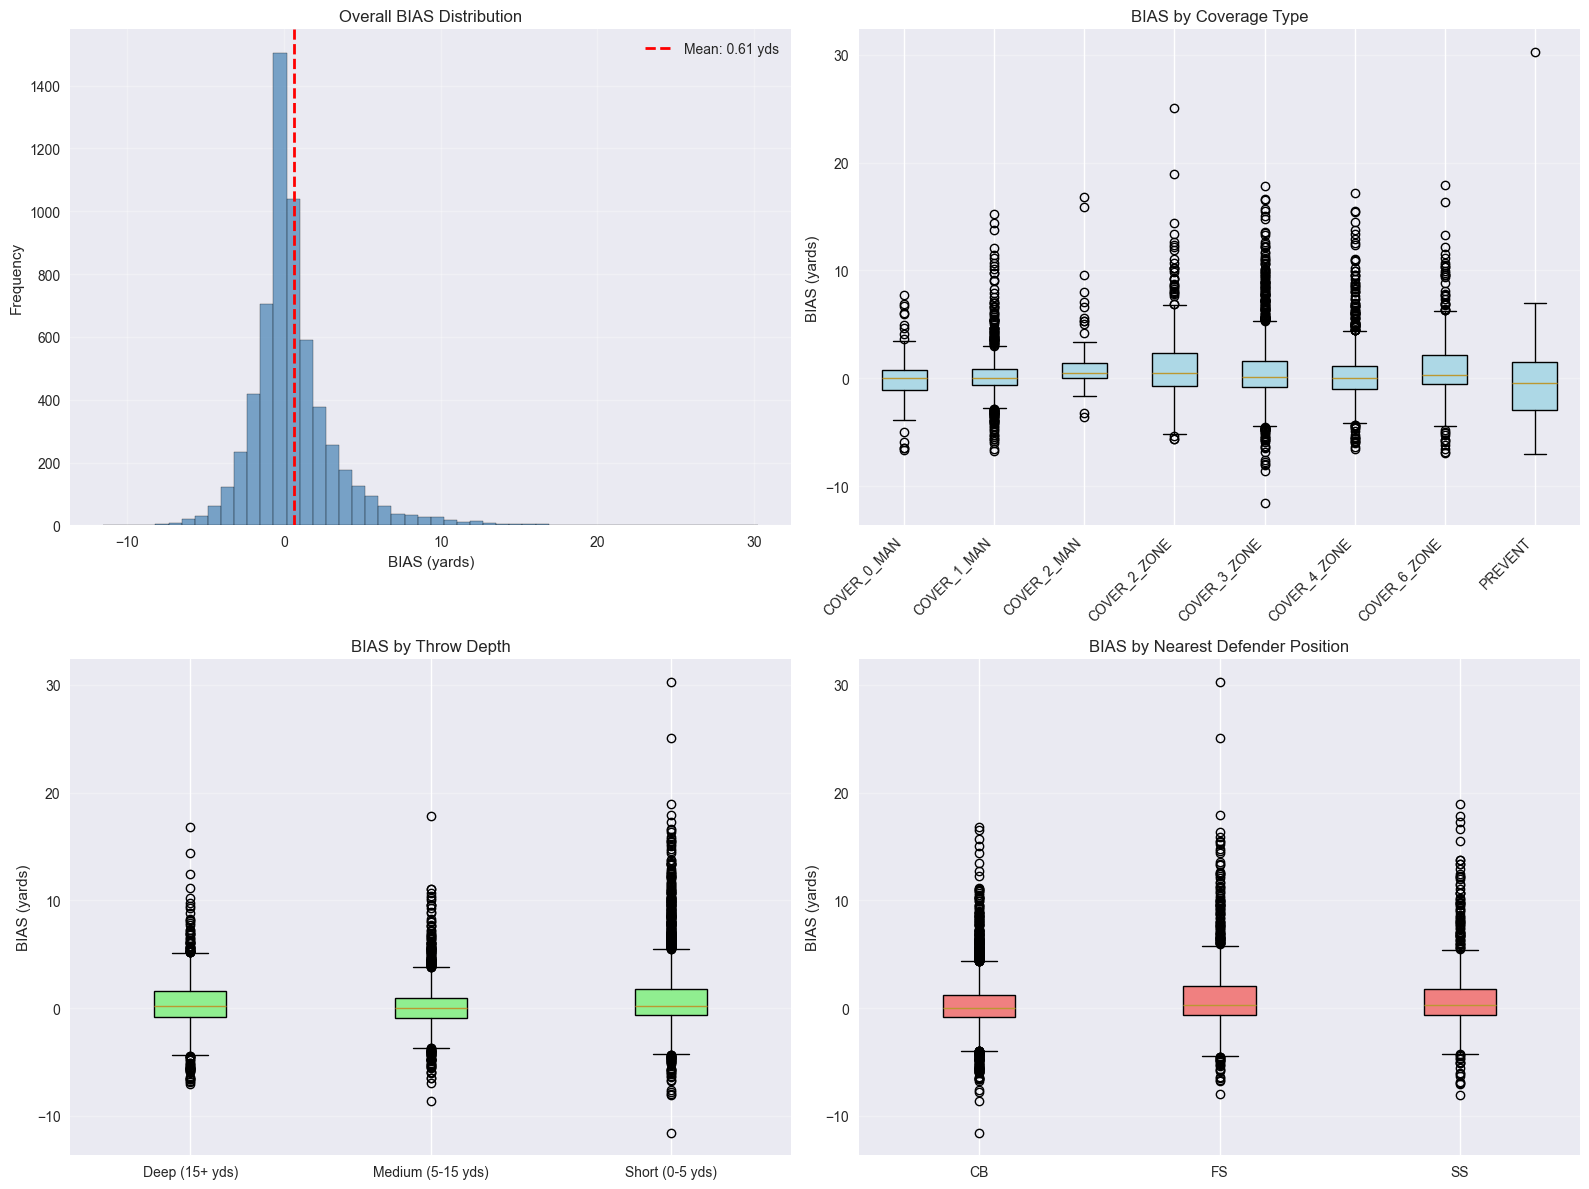

In [10]:
# =========================
# Cell 10 — Visualizations: BIAS Distributions
# =========================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Overall BIAS distribution
ax = axes[0, 0]
ax.hist(bias_analysis['bias'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(bias_analysis['bias'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {bias_analysis["bias"].mean():.2f} yds')
ax.set_xlabel('BIAS (yards)')
ax.set_ylabel('Frequency')
ax.set_title('Overall BIAS Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. BIAS by Coverage Type
ax = axes[0, 1]
coverage_order = sorted(bias_analysis['team_coverage_type'].dropna().unique())
bias_by_coverage = [bias_analysis[bias_analysis['team_coverage_type'] == cov]['bias'].dropna() 
                     for cov in coverage_order if len(bias_analysis[bias_analysis['team_coverage_type'] == cov]) > 0]
bp = ax.boxplot(bias_by_coverage, labels=[c for c in coverage_order if len(bias_analysis[bias_analysis['team_coverage_type'] == c]) > 0], 
                patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.set_ylabel('BIAS (yards)')
ax.set_title('BIAS by Coverage Type')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. BIAS by Throw Depth
ax = axes[1, 0]
depth_order = sorted(bias_analysis['throw_depth'].dropna().unique())
bias_by_depth = [bias_analysis[bias_analysis['throw_depth'] == depth]['bias'].dropna() 
                  for depth in depth_order if len(bias_analysis[bias_analysis['throw_depth'] == depth]) > 0]
bp = ax.boxplot(bias_by_depth, labels=[d for d in depth_order if len(bias_analysis[bias_analysis['throw_depth'] == d]) > 0], 
                patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
ax.set_ylabel('BIAS (yards)')
ax.set_title('BIAS by Throw Depth')
ax.grid(True, alpha=0.3, axis='y')

# 4. BIAS by Nearest Defender Position
ax = axes[1, 1]
defender_order = sorted(bias_analysis['nearest_defender_position'].dropna().unique())
bias_by_defender = [bias_analysis[bias_analysis['nearest_defender_position'] == pos]['bias'].dropna() 
                     for pos in defender_order if len(bias_analysis[bias_analysis['nearest_defender_position'] == pos]) > 0]
bp = ax.boxplot(bias_by_defender, labels=[p for p in defender_order if len(bias_analysis[bias_analysis['nearest_defender_position'] == p]) > 0], 
                patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightcoral')
ax.set_ylabel('BIAS (yards)')
ax.set_title('BIAS by Nearest Defender Position')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


BIAS BY COVERAGE TYPE AND THROW DEPTH

📊 Mean BIAS by Coverage Type and Throw Depth:
throw_depth         Short (0-5 yds)  Medium (5-15 yds)  Deep (15+ yds)
team_coverage_type                                                    
COVER_0_MAN                  0.2818            -0.7934         -0.2740
COVER_1_MAN                  0.4728             0.0702          0.2154
COVER_2_MAN                  1.5011             1.1982          1.4745
COVER_2_ZONE                 1.0080             0.8145          1.4876
COVER_3_ZONE                 1.0959             0.1187          0.3261
COVER_4_ZONE                 0.9707            -0.1303         -0.0965
COVER_6_ZONE                 1.1218             0.4382          0.9001
PREVENT                      4.0144             1.3012         -0.5892

📊 Sample Sizes:
throw_depth         Short (0-5 yds)  Medium (5-15 yds)  Deep (15+ yds)
team_coverage_type                                                    
COVER_0_MAN                     115           

/var/folders/7n/t_bt1q9s63n849ghblhw47hh0000gn/T/ipykernel_4870/1613444353.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_data = bias_analysis.groupby(['team_coverage_type', 'throw_depth'])['bias'].agg([


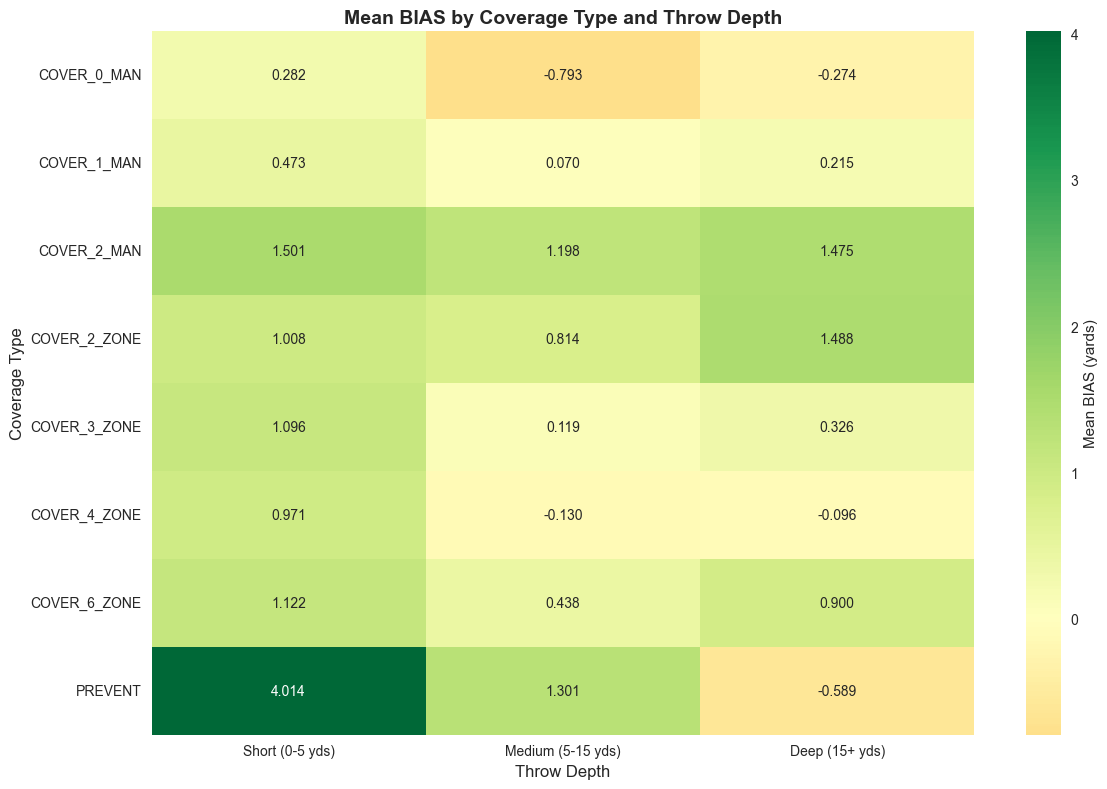

In [11]:
# =========================
# Cell 11 — BIAS by Coverage Type and Throw Depth (Combined Analysis)
# =========================
print("=" * 80)
print("BIAS BY COVERAGE TYPE AND THROW DEPTH")
print("=" * 80)

# Create a pivot table
pivot_data = bias_analysis.groupby(['team_coverage_type', 'throw_depth'])['bias'].agg([
    'mean', 'count', 'std'
]).reset_index()

pivot_table = pivot_data.pivot(index='team_coverage_type', columns='throw_depth', values='mean')
pivot_counts = pivot_data.pivot(index='team_coverage_type', columns='throw_depth', values='count')

print("\n📊 Mean BIAS by Coverage Type and Throw Depth:")
print(pivot_table.round(4))

print("\n📊 Sample Sizes:")
print(pivot_counts)

# Visualize the interaction
if len(pivot_table) > 0 and len(pivot_table.columns) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Create heatmap
    sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='RdYlGn', center=0, 
                cbar_kws={'label': 'Mean BIAS (yards)'}, ax=ax)
    ax.set_title('Mean BIAS by Coverage Type and Throw Depth', fontsize=14, fontweight='bold')
    ax.set_xlabel('Throw Depth', fontsize=12)
    ax.set_ylabel('Coverage Type', fontsize=12)
    
    plt.tight_layout()
    plt.show()


In [12]:
# =========================
# Cell 12 — Key Insights and Conclusions
# =========================
print("=" * 80)
print("KEY INSIGHTS AND CONCLUSIONS")
print("=" * 80)

print("\n📊 Overall BIAS Statistics:")
print(f"   Mean: {bias_analysis['bias'].mean():.4f} yards")
print(f"   Median: {bias_analysis['bias'].median():.4f} yards")
print(f"   Interpretation: On average, separation {'increases' if bias_analysis['bias'].mean() > 0 else 'decreases'} by {abs(bias_analysis['bias'].mean()):.2f} yards from release to catch")

print("\n🎯 Top Insights:")

# 1. Coverage type with highest BIAS
if len(coverage_df) > 0:
    best_coverage = coverage_df.loc[coverage_df['mean_bias'].idxmax()]
    worst_coverage = coverage_df.loc[coverage_df['mean_bias'].idxmin()]
    print(f"\n1. Coverage Type Impact:")
    print(f"   Best for receivers: {best_coverage['coverage_type']} (Mean BIAS: +{best_coverage['mean_bias']:.2f} yds)")
    print(f"   Worst for receivers: {worst_coverage['coverage_type']} (Mean BIAS: {worst_coverage['mean_bias']:+.2f} yds)")
    print(f"   Difference: {best_coverage['mean_bias'] - worst_coverage['mean_bias']:.2f} yards")

# 2. Throw depth with highest BIAS
if len(depth_df) > 0:
    best_depth = depth_df.loc[depth_df['mean_bias'].idxmax()]
    worst_depth = depth_df.loc[depth_df['mean_bias'].idxmin()]
    print(f"\n2. Throw Depth Impact:")
    print(f"   Best for receivers: {best_depth['throw_depth']} (Mean BIAS: +{best_depth['mean_bias']:.2f} yds)")
    print(f"   Worst for receivers: {worst_depth['throw_depth']} (Mean BIAS: {worst_depth['mean_bias']:+.2f} yds)")
    print(f"   Difference: {best_depth['mean_bias'] - worst_depth['mean_bias']:.2f} yards")

# 3. Defender position impact
defender_stats = bias_analysis.groupby('nearest_defender_position')['bias'].agg(['mean', 'count']).reset_index()
defender_stats = defender_stats.sort_values('mean', ascending=False)
print(f"\n3. Nearest Defender Position Impact:")
for _, row in defender_stats.iterrows():
    print(f"   {row['nearest_defender_position']}: Mean BIAS = {row['mean']:+.2f} yds (n={row['count']})")

print("\n" + "=" * 80)
print("✅ Analysis Complete!")
print("=" * 80)


KEY INSIGHTS AND CONCLUSIONS

📊 Overall BIAS Statistics:
   Mean: 0.6054 yards
   Median: 0.1006 yards
   Interpretation: On average, separation increases by 0.61 yards from release to catch

🎯 Top Insights:

1. Coverage Type Impact:
   Best for receivers: COVER_2_MAN (Mean BIAS: +1.37 yds)
   Worst for receivers: COVER_0_MAN (Mean BIAS: -0.07 yds)
   Difference: 1.44 yards

2. Throw Depth Impact:
   Best for receivers: Short (0-5 yds) (Mean BIAS: +0.94 yds)
   Worst for receivers: Medium (5-15 yds) (Mean BIAS: +0.16 yds)
   Difference: 0.78 yards

3. Nearest Defender Position Impact:
   FS: Mean BIAS = +1.07 yds (n=1158)
   SS: Mean BIAS = +0.93 yds (n=1012)
   CB: Mean BIAS = +0.38 yds (n=3855)

✅ Analysis Complete!


## Hypothesis: Negative BIAS = Defensive Success

**Hypothesis:** Negative BIAS (defender closing the gap) should be associated with defensive success (incomplete passes, interceptions).

We'll analyze:
- BIAS by coverage type AND throw depth
- Compare completed passes (offensive success) vs incomplete/intercepted (defensive success)
- Test if negative BIAS is more common on defensive successes


In [13]:
# =========================
# Cell 14 — BIAS by Coverage, Throw Depth, and Pass Result
# =========================
# Merge with play outcomes to get pass_result
plays_subset_full = plays[[
    'game_id', 'play_id', 'pass_result', 'pass_length', 
    'team_coverage_type', 'team_coverage_man_zone'
]].copy()

bias_full = bias_data.merge(
    plays_subset_full,
    on=['game_id', 'play_id'],
    how='left'
)

# Create throw depth categories
bias_full['throw_depth'] = pd.cut(
    bias_full['pass_length'],
    bins=[-np.inf, 5, 15, np.inf],
    labels=['Short (0-5 yds)', 'Medium (5-15 yds)', 'Deep (15+ yds)']
)

# Create defensive success indicator
# Defensive success = incomplete passes (I) or interceptions (IN)
bias_full['defensive_success'] = bias_full['pass_result'].isin(['I', 'IN']).astype(int)
bias_full['offensive_success'] = (bias_full['pass_result'] == 'C').astype(int)

print("=" * 80)
print("BIAS ANALYSIS: Defensive Success vs Offensive Success")
print("=" * 80)

print(f"\n📊 Overall Breakdown:")
print(f"   Defensive Success (I/IN): {bias_full['defensive_success'].sum()} plays")
print(f"   Offensive Success (C): {bias_full['offensive_success'].sum()} plays")
print(f"   Other: {len(bias_full) - bias_full['defensive_success'].sum() - bias_full['offensive_success'].sum()} plays")

# Filter to defensive and offensive successes
defensive_plays = bias_full[bias_full['defensive_success'] == 1].copy()
offensive_plays = bias_full[bias_full['offensive_success'] == 1].copy()

print(f"\n📊 BIAS Statistics:")
print(f"   Defensive Success Mean BIAS: {defensive_plays['bias'].mean():.4f} yards")
print(f"   Offensive Success Mean BIAS: {offensive_plays['bias'].mean():.4f} yards")
print(f"   Difference: {defensive_plays['bias'].mean() - offensive_plays['bias'].mean():.4f} yards")

# Percentage with negative BIAS
defensive_negative = (defensive_plays['bias'] < 0).sum()
offensive_negative = (offensive_plays['bias'] < 0).sum()

print(f"\n📊 Negative BIAS (Defender Closing Gap):")
print(f"   Defensive Success: {defensive_negative}/{len(defensive_plays)} ({100*defensive_negative/len(defensive_plays):.1f}%)")
print(f"   Offensive Success: {offensive_negative}/{len(offensive_plays)} ({100*offensive_negative/len(offensive_plays):.1f}%)")

# Statistical test
from scipy import stats
t_stat, p_val = stats.ttest_ind(defensive_plays['bias'], offensive_plays['bias'])
print(f"\n🔬 Statistical Test:")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''}")


BIAS ANALYSIS: Defensive Success vs Offensive Success

📊 Overall Breakdown:
   Defensive Success (I/IN): 2948 plays
   Offensive Success (C): 6025 plays
   Other: 0 plays

📊 BIAS Statistics:
   Defensive Success Mean BIAS: -0.1347 yards
   Offensive Success Mean BIAS: 0.6054 yards
   Difference: -0.7401 yards

📊 Negative BIAS (Defender Closing Gap):
   Defensive Success: 1642/2948 (55.7%)
   Offensive Success: 2552/6025 (42.4%)

🔬 Statistical Test:
   t-statistic: -12.4127
   p-value: 0.0000 ***


In [14]:
# =========================
# Cell 15 — BIAS by Coverage Type: Defensive vs Offensive Success
# =========================
print("=" * 80)
print("BIAS BY COVERAGE TYPE: Defensive Success vs Offensive Success")
print("=" * 80)

coverage_types = sorted(bias_full['team_coverage_type'].dropna().unique())

coverage_comparison = []

for coverage in coverage_types:
    def_coverage = defensive_plays[defensive_plays['team_coverage_type'] == coverage]
    off_coverage = offensive_plays[offensive_plays['team_coverage_type'] == coverage]
    
    if len(def_coverage) == 0 or len(off_coverage) == 0:
        continue
    
    def_mean = def_coverage['bias'].mean()
    off_mean = off_coverage['bias'].mean()
    def_neg_pct = 100 * (def_coverage['bias'] < 0).sum() / len(def_coverage)
    off_neg_pct = 100 * (off_coverage['bias'] < 0).sum() / len(off_coverage)
    
    coverage_comparison.append({
        'coverage_type': coverage,
        'defensive_success_mean_bias': def_mean,
        'offensive_success_mean_bias': off_mean,
        'difference': def_mean - off_mean,
        'defensive_negative_pct': def_neg_pct,
        'offensive_negative_pct': off_neg_pct,
        'defensive_n': len(def_coverage),
        'offensive_n': len(off_coverage),
    })
    
    print(f"\n📊 {coverage}:")
    print(f"   Defensive Success: Mean BIAS = {def_mean:+.4f} yds, {def_neg_pct:.1f}% negative (n={len(def_coverage)})")
    print(f"   Offensive Success: Mean BIAS = {off_mean:+.4f} yds, {off_neg_pct:.1f}% negative (n={len(off_coverage)})")
    print(f"   Difference: {def_mean - off_mean:+.4f} yds")
    
    # Statistical test
    if len(def_coverage) > 10 and len(off_coverage) > 10:
        t_stat, p_val = stats.ttest_ind(def_coverage['bias'], off_coverage['bias'])
        print(f"   p-value: {p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''}")

coverage_comp_df = pd.DataFrame(coverage_comparison)
print(f"\n\n📋 Summary Table:")
print(coverage_comp_df.to_string(index=False))


BIAS BY COVERAGE TYPE: Defensive Success vs Offensive Success

📊 COVER_0_MAN:
   Defensive Success: Mean BIAS = -0.3128 yds, 58.3% negative (n=127)
   Offensive Success: Mean BIAS = -0.0689 yds, 48.6% negative (n=185)
   Difference: -0.2439 yds
   p-value: 0.3303 

📊 COVER_1_MAN:
   Defensive Success: Mean BIAS = -0.3636 yds, 58.2% negative (n=820)
   Offensive Success: Mean BIAS = +0.2695 yds, 43.5% negative (n=1144)
   Difference: -0.6331 yds
   p-value: 0.0000 ***

📊 COVER_2_MAN:
   Defensive Success: Mean BIAS = +0.2290 yds, 42.3% negative (n=78)
   Offensive Success: Mean BIAS = +1.3684 yds, 24.4% negative (n=86)
   Difference: -1.1394 yds
   p-value: 0.0080 **

📊 COVER_2_ZONE:
   Defensive Success: Mean BIAS = +0.4450 yds, 44.9% negative (n=296)
   Offensive Success: Mean BIAS = +1.0415 yds, 36.2% negative (n=918)
   Difference: -0.5965 yds
   p-value: 0.0017 **

📊 COVER_3_ZONE:
   Defensive Success: Mean BIAS = -0.1302 yds, 57.1% negative (n=867)
   Offensive Success: Mean BIAS 

In [15]:
# =========================
# Cell 16 — BIAS by Throw Depth: Defensive vs Offensive Success
# =========================
print("=" * 80)
print("BIAS BY THROW DEPTH: Defensive Success vs Offensive Success")
print("=" * 80)

throw_depths = sorted(bias_full['throw_depth'].dropna().unique())

depth_comparison = []

for depth in throw_depths:
    def_depth = defensive_plays[defensive_plays['throw_depth'] == depth]
    off_depth = offensive_plays[offensive_plays['throw_depth'] == depth]
    
    if len(def_depth) == 0 or len(off_depth) == 0:
        continue
    
    def_mean = def_depth['bias'].mean()
    off_mean = off_depth['bias'].mean()
    def_neg_pct = 100 * (def_depth['bias'] < 0).sum() / len(def_depth)
    off_neg_pct = 100 * (off_depth['bias'] < 0).sum() / len(off_depth)
    
    depth_comparison.append({
        'throw_depth': depth,
        'defensive_success_mean_bias': def_mean,
        'offensive_success_mean_bias': off_mean,
        'difference': def_mean - off_mean,
        'defensive_negative_pct': def_neg_pct,
        'offensive_negative_pct': off_neg_pct,
        'defensive_n': len(def_depth),
        'offensive_n': len(off_depth),
    })
    
    print(f"\n📊 {depth}:")
    print(f"   Defensive Success: Mean BIAS = {def_mean:+.4f} yds, {def_neg_pct:.1f}% negative (n={len(def_depth)})")
    print(f"   Offensive Success: Mean BIAS = {off_mean:+.4f} yds, {off_neg_pct:.1f}% negative (n={len(off_depth)})")
    print(f"   Difference: {def_mean - off_mean:+.4f} yds")
    
    # Statistical test
    if len(def_depth) > 10 and len(off_depth) > 10:
        t_stat, p_val = stats.ttest_ind(def_depth['bias'], off_depth['bias'])
        print(f"   p-value: {p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''}")

depth_comp_df = pd.DataFrame(depth_comparison)
print(f"\n\n📋 Summary Table:")
print(depth_comp_df.to_string(index=False))


BIAS BY THROW DEPTH: Defensive Success vs Offensive Success

📊 Deep (15+ yds):
   Defensive Success: Mean BIAS = -0.3750 yds, 58.4% negative (n=1162)
   Offensive Success: Mean BIAS = +0.4677 yds, 42.4% negative (n=1039)
   Difference: -0.8427 yds
   p-value: 0.0000 ***

📊 Medium (5-15 yds):
   Defensive Success: Mean BIAS = -0.3123 yds, 57.7% negative (n=1054)
   Offensive Success: Mean BIAS = +0.1601 yds, 46.6% negative (n=1963)
   Difference: -0.4725 yds
   p-value: 0.0000 ***

📊 Short (0-5 yds):
   Defensive Success: Mean BIAS = +0.5027 yds, 48.5% negative (n=732)
   Offensive Success: Mean BIAS = +0.9419 yds, 39.6% negative (n=3023)
   Difference: -0.4392 yds
   p-value: 0.0005 ***


📋 Summary Table:
      throw_depth  defensive_success_mean_bias  offensive_success_mean_bias  difference  defensive_negative_pct  offensive_negative_pct  defensive_n  offensive_n
   Deep (15+ yds)                    -0.375004                     0.467680   -0.842684               58.433735            

In [16]:
# =========================
# Cell 17 — BIAS by Coverage Type AND Throw Depth: Combined Analysis
# =========================
print("=" * 80)
print("BIAS BY COVERAGE TYPE AND THROW DEPTH: Defensive vs Offensive Success")
print("=" * 80)

# Create pivot tables for defensive success
def_pivot = defensive_plays.groupby(['team_coverage_type', 'throw_depth'])['bias'].agg([
    'mean', 'count', lambda x: (x < 0).sum() / len(x) * 100
]).reset_index()
def_pivot.columns = ['coverage_type', 'throw_depth', 'mean_bias', 'n_plays', 'pct_negative']

# Create pivot tables for offensive success
off_pivot = offensive_plays.groupby(['team_coverage_type', 'throw_depth'])['bias'].agg([
    'mean', 'count', lambda x: (x < 0).sum() / len(x) * 100
]).reset_index()
off_pivot.columns = ['coverage_type', 'throw_depth', 'mean_bias', 'n_plays', 'pct_negative']

# Merge for comparison
combined = def_pivot.merge(
    off_pivot,
    on=['coverage_type', 'throw_depth'],
    suffixes=('_def', '_off'),
    how='outer'
)

combined['bias_difference'] = combined['mean_bias_def'] - combined['mean_bias_off']
combined['neg_pct_difference'] = combined['pct_negative_def'] - combined['pct_negative_off']

print("\n📊 Mean BIAS by Coverage Type and Throw Depth:")
print("\nDefensive Success (Incomplete/Intercepted):")
print(def_pivot.pivot(index='coverage_type', columns='throw_depth', values='mean_bias').round(3))

print("\nOffensive Success (Completed):")
print(off_pivot.pivot(index='coverage_type', columns='throw_depth', values='mean_bias').round(3))

print("\nDifference (Defensive - Offensive):")
print(combined.pivot(index='coverage_type', columns='throw_depth', values='bias_difference').round(3))

print("\n📊 Percentage with Negative BIAS:")
print("\nDefensive Success:")
print(def_pivot.pivot(index='coverage_type', columns='throw_depth', values='pct_negative').round(1))

print("\nOffensive Success:")
print(off_pivot.pivot(index='coverage_type', columns='throw_depth', values='pct_negative').round(1))

print("\nDifference (Defensive - Offensive):")
print(combined.pivot(index='coverage_type', columns='throw_depth', values='neg_pct_difference').round(1))


BIAS BY COVERAGE TYPE AND THROW DEPTH: Defensive vs Offensive Success

📊 Mean BIAS by Coverage Type and Throw Depth:

Defensive Success (Incomplete/Intercepted):
throw_depth    Short (0-5 yds)  Medium (5-15 yds)  Deep (15+ yds)
coverage_type                                                    
COVER_0_MAN              0.255             -1.071          -0.647
COVER_1_MAN             -0.173             -0.449          -0.381
COVER_2_MAN              0.063              0.256           0.263
COVER_2_ZONE             0.343              0.527           0.487
COVER_3_ZONE             0.898             -0.311          -0.501
COVER_4_ZONE             1.031             -0.329          -1.067
COVER_6_ZONE             0.781             -0.339           0.033
PREVENT                    NaN             -0.811          -0.703

Offensive Success (Completed):


/var/folders/7n/t_bt1q9s63n849ghblhw47hh0000gn/T/ipykernel_4870/279349735.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  def_pivot = defensive_plays.groupby(['team_coverage_type', 'throw_depth'])['bias'].agg([
/var/folders/7n/t_bt1q9s63n849ghblhw47hh0000gn/T/ipykernel_4870/279349735.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  off_pivot = offensive_plays.groupby(['team_coverage_type', 'throw_depth'])['bias'].agg([


throw_depth    Short (0-5 yds)  Medium (5-15 yds)  Deep (15+ yds)
coverage_type                                                    
COVER_0_MAN              0.282             -0.793          -0.274
COVER_1_MAN              0.473              0.070           0.215
COVER_2_MAN              1.501              1.198           1.475
COVER_2_ZONE             1.008              0.814           1.488
COVER_3_ZONE             1.096              0.119           0.326
COVER_4_ZONE             0.971             -0.130          -0.096
COVER_6_ZONE             1.122              0.438           0.900
PREVENT                  4.014              1.301          -0.589

Difference (Defensive - Offensive):
throw_depth    Short (0-5 yds)  Medium (5-15 yds)  Deep (15+ yds)
coverage_type                                                    
COVER_0_MAN             -0.027             -0.278          -0.373
COVER_1_MAN             -0.646             -0.520          -0.596
COVER_2_MAN             -1.439         

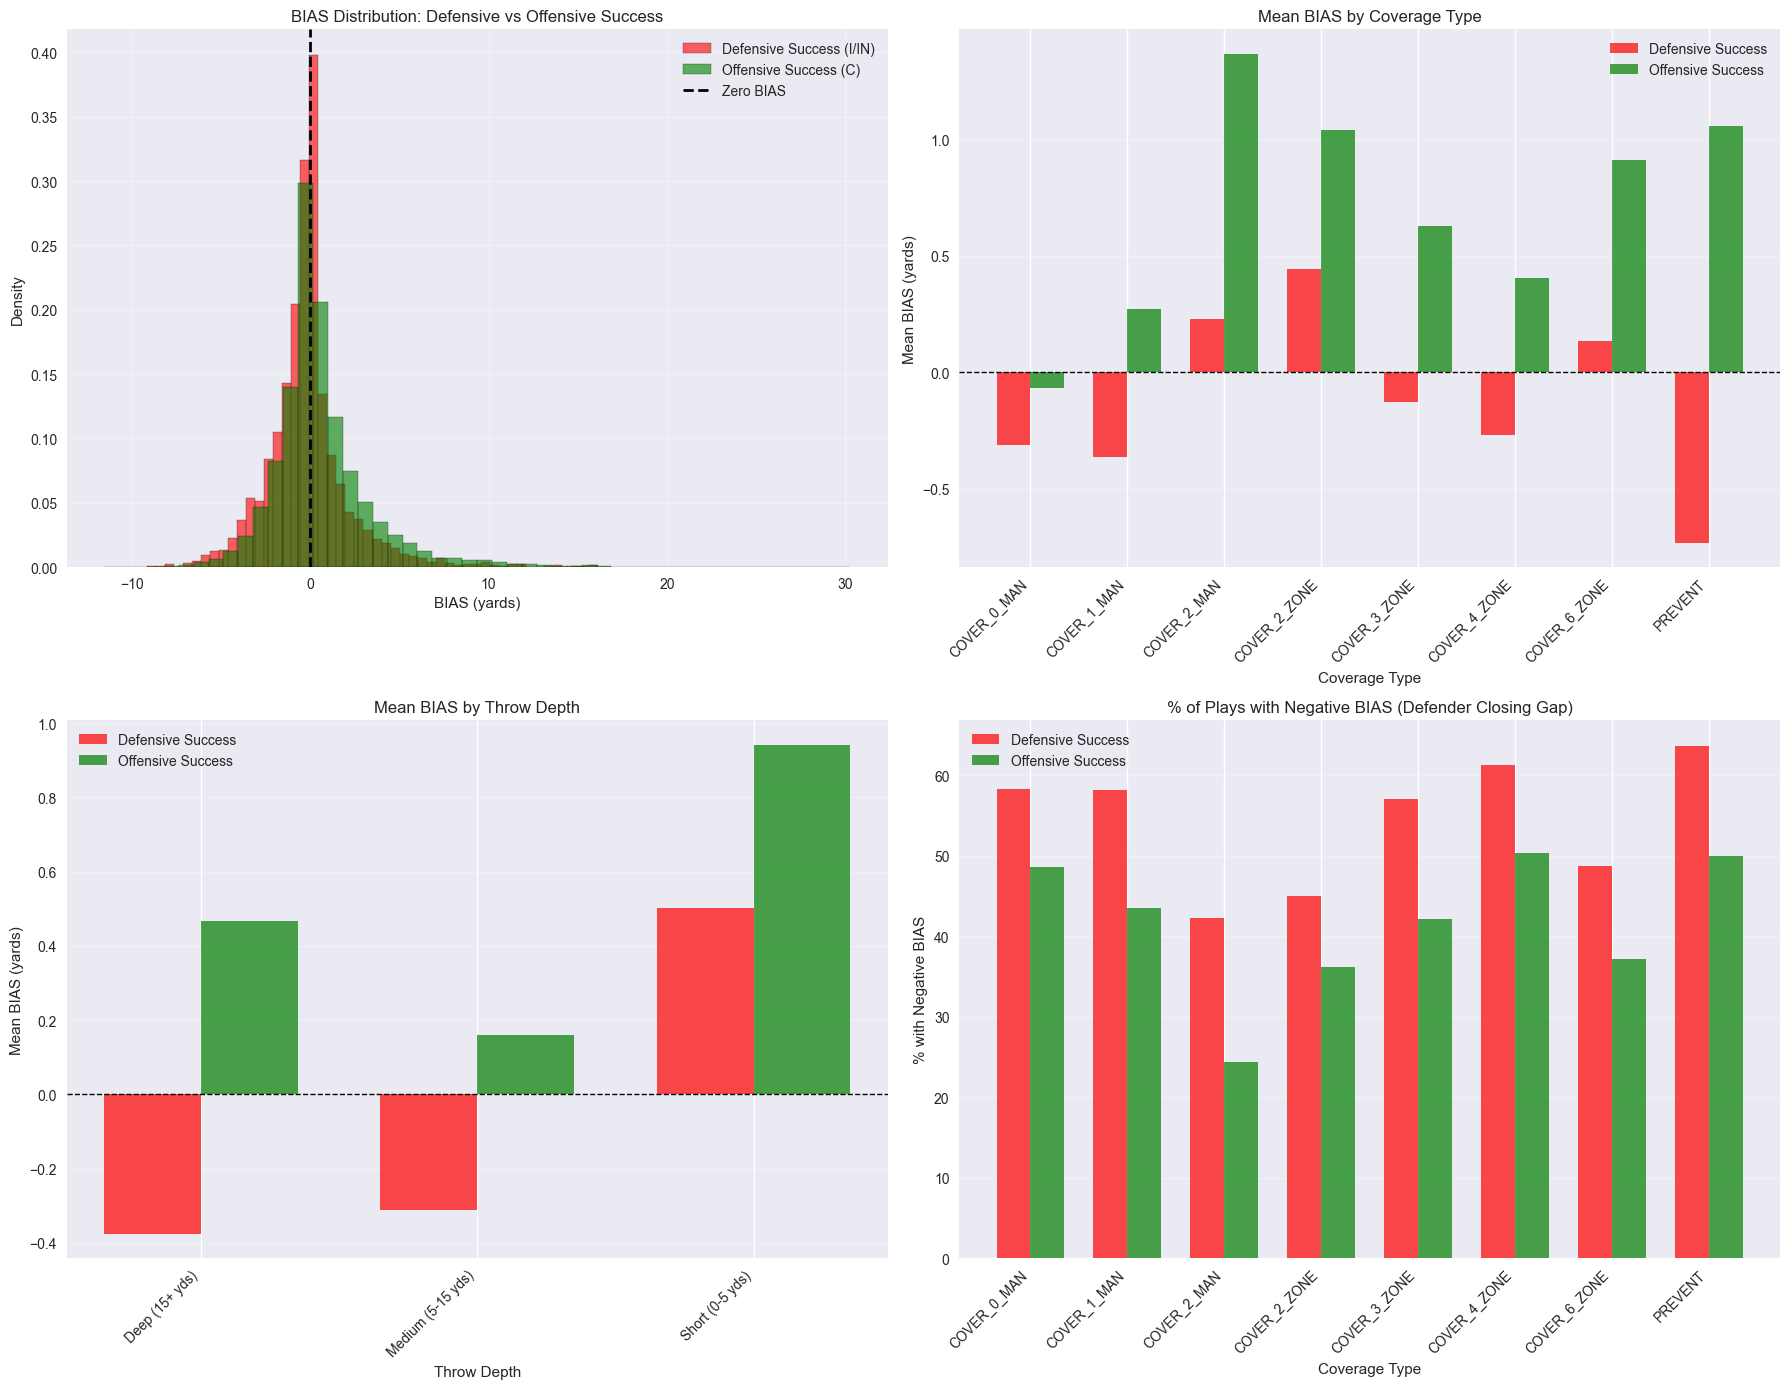

In [17]:
# =========================
# Cell 18 — Visualizations: BIAS by Coverage, Depth, and Outcome
# =========================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Overall BIAS distribution: Defensive vs Offensive Success
ax = axes[0, 0]
ax.hist(defensive_plays['bias'], bins=50, alpha=0.6, label='Defensive Success (I/IN)', 
        color='red', density=True, edgecolor='black')
ax.hist(offensive_plays['bias'], bins=50, alpha=0.6, label='Offensive Success (C)', 
        color='green', density=True, edgecolor='black')
ax.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero BIAS')
ax.set_xlabel('BIAS (yards)')
ax.set_ylabel('Density')
ax.set_title('BIAS Distribution: Defensive vs Offensive Success')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Mean BIAS by Coverage Type
ax = axes[0, 1]
coverage_order = sorted(coverage_comp_df['coverage_type'].unique())
x_pos = np.arange(len(coverage_order))
width = 0.35

def_means = [coverage_comp_df[coverage_comp_df['coverage_type'] == c]['defensive_success_mean_bias'].iloc[0] 
             if len(coverage_comp_df[coverage_comp_df['coverage_type'] == c]) > 0 else 0 
             for c in coverage_order]
off_means = [coverage_comp_df[coverage_comp_df['coverage_type'] == c]['offensive_success_mean_bias'].iloc[0] 
             if len(coverage_comp_df[coverage_comp_df['coverage_type'] == c]) > 0 else 0 
             for c in coverage_order]

ax.bar(x_pos - width/2, def_means, width, label='Defensive Success', color='red', alpha=0.7)
ax.bar(x_pos + width/2, off_means, width, label='Offensive Success', color='green', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Coverage Type')
ax.set_ylabel('Mean BIAS (yards)')
ax.set_title('Mean BIAS by Coverage Type')
ax.set_xticks(x_pos)
ax.set_xticklabels(coverage_order, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 3. Mean BIAS by Throw Depth
ax = axes[1, 0]
depth_order = sorted(depth_comp_df['throw_depth'].unique())
x_pos = np.arange(len(depth_order))
width = 0.35

def_means = [depth_comp_df[depth_comp_df['throw_depth'] == d]['defensive_success_mean_bias'].iloc[0] 
             if len(depth_comp_df[depth_comp_df['throw_depth'] == d]) > 0 else 0 
             for d in depth_order]
off_means = [depth_comp_df[depth_comp_df['throw_depth'] == d]['offensive_success_mean_bias'].iloc[0] 
             if len(depth_comp_df[depth_comp_df['throw_depth'] == d]) > 0 else 0 
             for d in depth_order]

ax.bar(x_pos - width/2, def_means, width, label='Defensive Success', color='red', alpha=0.7)
ax.bar(x_pos + width/2, off_means, width, label='Offensive Success', color='green', alpha=0.7)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Throw Depth')
ax.set_ylabel('Mean BIAS (yards)')
ax.set_title('Mean BIAS by Throw Depth')
ax.set_xticks(x_pos)
ax.set_xticklabels(depth_order, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Percentage with Negative BIAS
ax = axes[1, 1]
coverage_order = sorted(coverage_comp_df['coverage_type'].unique())
x_pos = np.arange(len(coverage_order))
width = 0.35

def_neg = [coverage_comp_df[coverage_comp_df['coverage_type'] == c]['defensive_negative_pct'].iloc[0] 
           if len(coverage_comp_df[coverage_comp_df['coverage_type'] == c]) > 0 else 0 
           for c in coverage_order]
off_neg = [coverage_comp_df[coverage_comp_df['coverage_type'] == c]['offensive_negative_pct'].iloc[0] 
           if len(coverage_comp_df[coverage_comp_df['coverage_type'] == c]) > 0 else 0 
           for c in coverage_order]

ax.bar(x_pos - width/2, def_neg, width, label='Defensive Success', color='red', alpha=0.7)
ax.bar(x_pos + width/2, off_neg, width, label='Offensive Success', color='green', alpha=0.7)
ax.set_xlabel('Coverage Type')
ax.set_ylabel('% with Negative BIAS')
ax.set_title('% of Plays with Negative BIAS (Defender Closing Gap)')
ax.set_xticks(x_pos)
ax.set_xticklabels(coverage_order, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


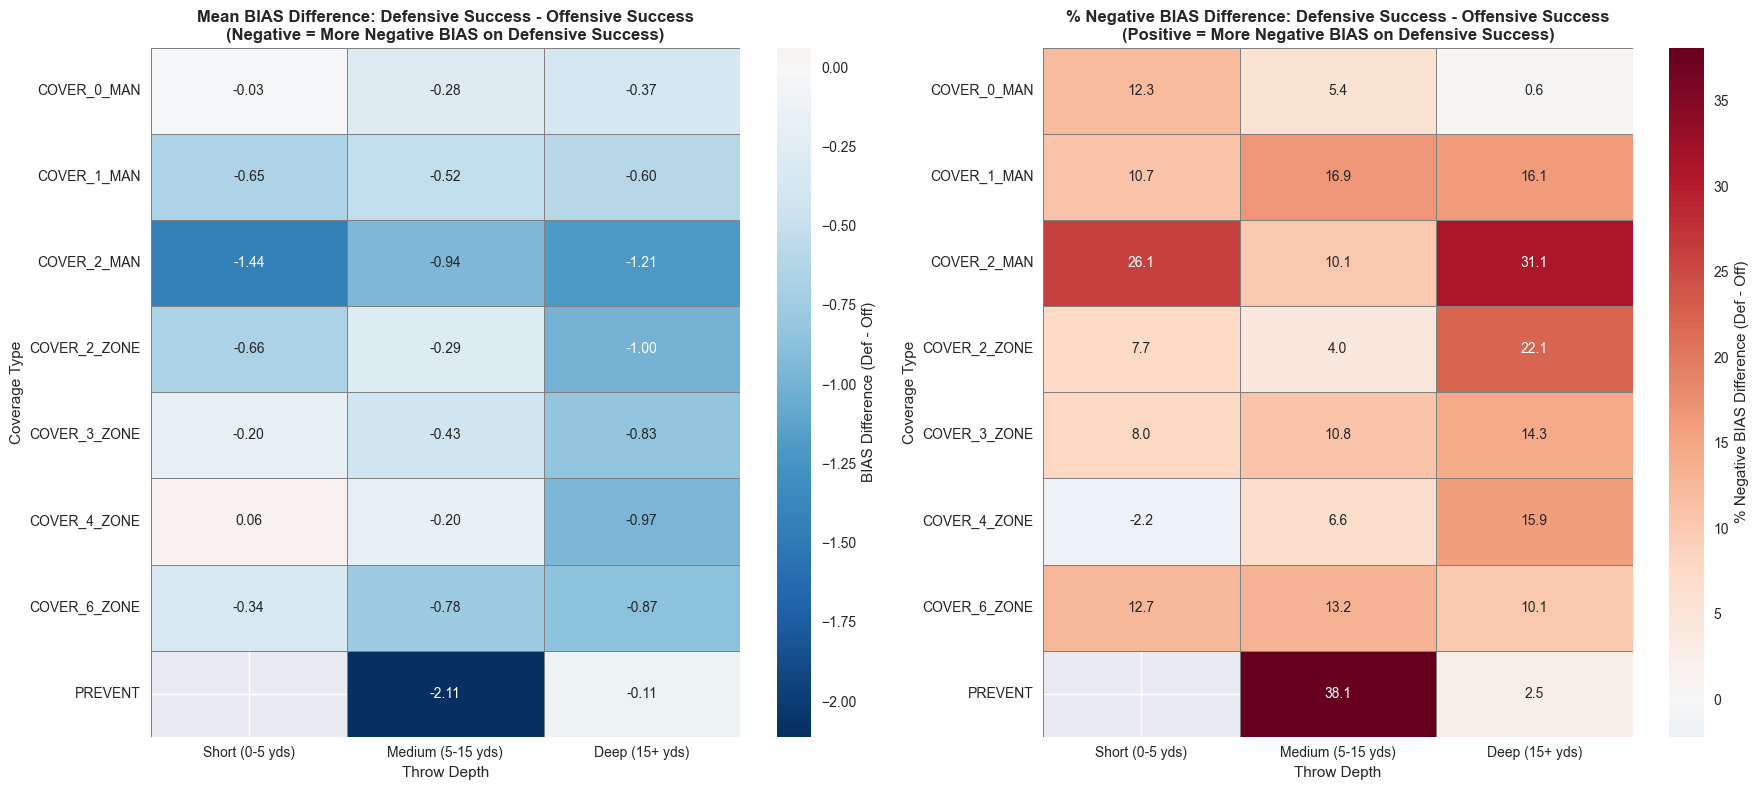

In [18]:
# =========================
# Cell 19 — Heatmap: BIAS Difference by Coverage and Throw Depth
# =========================
# Create heatmap showing difference in mean BIAS (Defensive Success - Offensive Success)
pivot_diff = combined.pivot(index='coverage_type', columns='throw_depth', values='bias_difference')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap 1: Mean BIAS Difference
ax = axes[0]
sns.heatmap(pivot_diff, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'BIAS Difference (Def - Off)'}, ax=ax, 
            linewidths=0.5, linecolor='gray')
ax.set_title('Mean BIAS Difference: Defensive Success - Offensive Success\n(Negative = More Negative BIAS on Defensive Success)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Throw Depth', fontsize=11)
ax.set_ylabel('Coverage Type', fontsize=11)

# Heatmap 2: Percentage Negative BIAS Difference
pivot_neg_diff = combined.pivot(index='coverage_type', columns='throw_depth', values='neg_pct_difference')
ax = axes[1]
sns.heatmap(pivot_neg_diff, annot=True, fmt='.1f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': '% Negative BIAS Difference (Def - Off)'}, ax=ax,
            linewidths=0.5, linecolor='gray')
ax.set_title('% Negative BIAS Difference: Defensive Success - Offensive Success\n(Positive = More Negative BIAS on Defensive Success)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Throw Depth', fontsize=11)
ax.set_ylabel('Coverage Type', fontsize=11)

plt.tight_layout()
plt.show()


In [19]:
# =========================
# Cell 20 — Hypothesis Testing: Negative BIAS and Defensive Success
# =========================
print("=" * 80)
print("HYPOTHESIS TESTING: Negative BIAS = Defensive Success")
print("=" * 80)

print("\n📊 Overall Results:")
print(f"   Defensive Success Mean BIAS: {defensive_plays['bias'].mean():.4f} yards")
print(f"   Offensive Success Mean BIAS: {offensive_plays['bias'].mean():.4f} yards")
print(f"   Difference: {defensive_plays['bias'].mean() - offensive_plays['bias'].mean():.4f} yards")

print(f"\n📊 Negative BIAS Frequency:")
def_neg_pct = 100 * (defensive_plays['bias'] < 0).sum() / len(defensive_plays)
off_neg_pct = 100 * (offensive_plays['bias'] < 0).sum() / len(offensive_plays)
print(f"   Defensive Success: {def_neg_pct:.1f}% have negative BIAS")
print(f"   Offensive Success: {off_neg_pct:.1f}% have negative BIAS")
print(f"   Difference: {def_neg_pct - off_neg_pct:.1f} percentage points")

# Statistical test: Chi-square test for independence
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    bias_full['defensive_success'], 
    bias_full['bias'] < 0
)
chi2, p_val, dof, expected = chi2_contingency(contingency)

print(f"\n🔬 Statistical Tests:")
print(f"   Chi-square test (negative BIAS vs defensive success):")
print(f"   Chi-square statistic: {chi2:.4f}")
print(f"   p-value: {p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''}")

# T-test
t_stat, p_val_ttest = stats.ttest_ind(defensive_plays['bias'], offensive_plays['bias'])
print(f"\n   T-test (mean BIAS difference):")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_val_ttest:.4f} {'***' if p_val_ttest < 0.001 else '**' if p_val_ttest < 0.01 else '*' if p_val_ttest < 0.05 else ''}")

print("\n" + "=" * 80)
print("CONCLUSION:")
print("=" * 80)

if defensive_plays['bias'].mean() < offensive_plays['bias'].mean():
    print("✅ HYPOTHESIS SUPPORTED: Defensive success has lower (more negative) BIAS")
    print(f"   Defenders close the gap more on incomplete/intercepted passes")
else:
    print("❌ HYPOTHESIS NOT SUPPORTED: Defensive success does not show more negative BIAS")
    print(f"   Mean BIAS is actually higher on defensive successes")

if def_neg_pct > off_neg_pct:
    print(f"\n✅ SUPPORTING EVIDENCE: {def_neg_pct:.1f}% of defensive successes have negative BIAS")
    print(f"   vs {off_neg_pct:.1f}% of offensive successes")
    print(f"   This suggests defenders closing the gap is associated with defensive success")
else:
    print(f"\n⚠️  MIXED EVIDENCE: Negative BIAS is not more common on defensive successes")

print("\n✅ Analysis Complete!")


HYPOTHESIS TESTING: Negative BIAS = Defensive Success

📊 Overall Results:
   Defensive Success Mean BIAS: -0.1347 yards
   Offensive Success Mean BIAS: 0.6054 yards
   Difference: -0.7401 yards

📊 Negative BIAS Frequency:
   Defensive Success: 55.7% have negative BIAS
   Offensive Success: 42.4% have negative BIAS
   Difference: 13.3 percentage points

🔬 Statistical Tests:
   Chi-square test (negative BIAS vs defensive success):
   Chi-square statistic: 141.0094
   p-value: 0.0000 ***

   T-test (mean BIAS difference):
   t-statistic: -12.4127
   p-value: 0.0000 ***

CONCLUSION:
✅ HYPOTHESIS SUPPORTED: Defensive success has lower (more negative) BIAS
   Defenders close the gap more on incomplete/intercepted passes

✅ SUPPORTING EVIDENCE: 55.7% of defensive successes have negative BIAS
   vs 42.4% of offensive successes
   This suggests defenders closing the gap is associated with defensive success

✅ Analysis Complete!


## Standout Players and Plays Analysis

Identify specific players and plays with exceptional negative BIAS (defender closing the gap).


In [21]:
# =========================
# Cell 22 — Top Players by Negative BIAS (Defensive Success)
# =========================
print("=" * 80)
print("TOP DEFENDERS: Most Negative BIAS on Defensive Success Plays")
print("=" * 80)

# Make sure defensive_plays is defined (from Cell 14)
if 'defensive_plays' not in locals():
    print("⚠️  Run Cell 14 first to define defensive_plays")
    defensive_negative = pd.DataFrame()
else:
    # Focus on defensive success plays with negative BIAS
    defensive_negative = defensive_plays[defensive_plays['bias'] < 0].copy()

if len(defensive_negative) > 0:
    # Get defender information from separation data
    # We need to merge back to get defender names
    if 'separation_data' not in locals():
        print("⚠️  separation_data not found. Run Cell 5 first.")
        defender_bias = defensive_negative.copy()
        # Add placeholder columns if they don't exist
        if 'nearest_defender_name' not in defender_bias.columns:
            defender_bias['nearest_defender_name'] = 'Unknown'
        if 'nearest_defender_nfl_id' not in defender_bias.columns:
            defender_bias['nearest_defender_nfl_id'] = -1
    else:
        separation_with_defenders = separation_data[['play_id', 'target_nfl_id', 'nearest_defender_nfl_id', 
                                                     'nearest_defender_name', 'nearest_defender_position']].drop_duplicates(subset=['play_id', 'target_nfl_id'])
        
        defender_bias = defensive_negative.merge(
            separation_with_defenders,
            on=['play_id', 'target_nfl_id'],
            how='left'
        )

    # Check if we have defender information
    if 'nearest_defender_name' not in defender_bias.columns or defender_bias['nearest_defender_name'].isna().all():
        print("⚠️  Defender information not available. Using position only.")
        # Use position if available, otherwise skip
        if 'nearest_defender_position' in defender_bias.columns:
            defender_bias['nearest_defender_name'] = defender_bias['nearest_defender_position'].fillna('Unknown')
            defender_bias['nearest_defender_nfl_id'] = -1
        else:
            print("⚠️  Cannot aggregate by defender - missing defender information")
            defender_stats = pd.DataFrame()
            defender_total = pd.DataFrame()
    else:
        # Fill missing values
        defender_bias['nearest_defender_name'] = defender_bias['nearest_defender_name'].fillna('Unknown')
        defender_bias['nearest_defender_nfl_id'] = defender_bias['nearest_defender_nfl_id'].fillna(-1)
        if 'nearest_defender_position' not in defender_bias.columns:
            defender_bias['nearest_defender_position'] = 'Unknown'
    
    # Aggregate by defender (only if we have the data)
    if len(defender_bias) > 0 and 'nearest_defender_name' in defender_bias.columns:
        defender_stats = defender_bias.groupby(['nearest_defender_nfl_id', 'nearest_defender_name', 
                                                'nearest_defender_position']).agg({
            'bias': ['mean', 'count', 'min'],
            'separation_release': 'mean',
            'separation_catch': 'mean',
        }).reset_index()
        
        defender_stats.columns = ['nfl_id', 'defender_name', 'position', 'mean_bias', 'n_plays', 
                                  'min_bias', 'avg_sep_release', 'avg_sep_catch']
        
        # Filter to defenders with at least 3 plays
        defender_stats = defender_stats[defender_stats['n_plays'] >= 3].copy()
        defender_stats = defender_stats.sort_values('mean_bias')  # Most negative first
        
        print("\n🏆 Top 20 Defenders by Mean Negative BIAS (Defensive Success):")
        if len(defender_stats) > 0:
            print(defender_stats.head(20).to_string(index=False))
        else:
            print("   No defenders with at least 3 plays")
        
        # Also look at total plays with negative BIAS
        defender_total = defender_bias.groupby(['nearest_defender_nfl_id', 'nearest_defender_name', 
                                                'nearest_defender_position']).agg({
            'bias': 'count'
        }).reset_index()
        defender_total.columns = ['nfl_id', 'defender_name', 'position', 'total_negative_bias_plays']
        defender_total = defender_total.sort_values('total_negative_bias_plays', ascending=False)
        
        print("\n\n🏆 Top 20 Defenders by Total Plays with Negative BIAS:")
        if len(defender_total) > 0:
            print(defender_total.head(20).to_string(index=False))
        else:
            print("   No defender data available")
    else:
        print("⚠️  Cannot aggregate by defender - missing required data")
        defender_stats = pd.DataFrame()
        defender_total = pd.DataFrame()
else:
    print("⚠️  No defensive negative plays found. Run previous cells first.")
    defender_stats = pd.DataFrame()
    defender_total = pd.DataFrame()


TOP DEFENDERS: Most Negative BIAS on Defensive Success Plays

🏆 Top 20 Defenders by Mean Negative BIAS (Defensive Success):
 nfl_id      defender_name position  mean_bias  n_plays  min_bias  avg_sep_release  avg_sep_catch
  52444    Xavier McKinney  Unknown  -4.917282        3 -6.604570         6.919820       2.002537
  55978 Clark Phillips III  Unknown  -3.804299        4 -5.528170         5.896300       2.092001
  43314        Artie Burns  Unknown  -3.713384        3 -5.222251         5.605346       1.891962
  52493    Julian Blackmon  Unknown  -3.239295        6 -5.662560         5.866589       2.627294
  53609    Talanoa Hufanga  Unknown  -2.934989        3 -6.287205         4.900912       1.965923
  46248    Parry Nickerson  Unknown  -2.925587        3 -4.627168         6.661371       3.735784
  53531       Ambry Thomas  Unknown  -2.848753        6 -9.160300         8.004335       5.155582
  47941       Mike Jackson  Unknown  -2.700571        4 -5.194154         5.053111       2.3

In [23]:
# =========================
# Cell 23 — Standout Plays with Extreme Negative BIAS
# =========================
print("=" * 80)
print("STANDOUT PLAYS: Most Extreme Negative BIAS")
print("=" * 80)

# Get play details for standout plays
if 'defensive_negative' in locals() and len(defensive_negative) > 0:
    standout_plays = defensive_negative.nsmallest(20, 'bias').copy()
else:
    print("⚠️  Run Cell 22 first to define defensive_negative")
    standout_plays = pd.DataFrame()

if len(standout_plays) > 0:
    # Merge with play information
    standout_plays = standout_plays.merge(
        plays[['game_id', 'play_id', 'play_description', 'pass_length', 'team_coverage_type']],
        on=['game_id', 'play_id'],
        how='left'
    )
    
    # Add throw_depth if not already present
    if 'throw_depth' not in standout_plays.columns:
        standout_plays['throw_depth'] = pd.cut(
            standout_plays['pass_length'],
            bins=[-np.inf, 5, 15, np.inf],
            labels=['Short (0-5 yds)', 'Medium (5-15 yds)', 'Deep (15+ yds)']
        )
    
    # Get defender information from separation_data if available
    if 'separation_data' in locals() and len(separation_data) > 0:
        separation_defenders = separation_data[['play_id', 'target_nfl_id', 'nearest_defender_nfl_id',
                                               'nearest_defender_name', 'nearest_defender_position']].drop_duplicates(
            subset=['play_id', 'target_nfl_id']
        )
        standout_plays = standout_plays.merge(
            separation_defenders,
            on=['play_id', 'target_nfl_id'],
            how='left'
        )
    else:
        # Add placeholder columns if separation_data not available
        if 'nearest_defender_name' not in standout_plays.columns:
            standout_plays['nearest_defender_name'] = standout_plays.get('nearest_defender_position', 'Unknown')
        if 'nearest_defender_position' not in standout_plays.columns:
            standout_plays['nearest_defender_position'] = 'Unknown'
    
    print("\n🎯 Top 20 Plays with Most Negative BIAS (Defender Closing Gap):")
    print("\nColumns: Play ID | Defender | BIAS | Coverage | Throw Depth | Description")
    for idx, row in standout_plays.iterrows():
        print(f"\nPlay {row['play_id']}:")
        defender_name = row.get('nearest_defender_name', row.get('nearest_defender_position', 'N/A'))
        defender_pos = row.get('nearest_defender_position', 'N/A')
        print(f"   Defender: {defender_name} ({defender_pos})")
        print(f"   BIAS: {row['bias']:.2f} yards (closed {abs(row['bias']):.2f} yards)")
        print(f"   Coverage: {row.get('team_coverage_type', 'N/A')}")
        print(f"   Throw Depth: {row.get('throw_depth', 'N/A')}")
        desc = row.get('play_description', 'N/A')
        if isinstance(desc, str) and len(desc) > 100:
            desc = desc[:100] + '...'
        print(f"   Description: {desc}")
    
    # Also show some examples of successful defensive plays
    print("\n\n📊 Sample Standout Plays DataFrame:")
    display_cols = ['play_id', 'target_name', 'bias', 'separation_release', 'separation_catch', 'team_coverage_type']
    if 'nearest_defender_name' in standout_plays.columns:
        display_cols.insert(2, 'nearest_defender_name')
    if 'nearest_defender_position' in standout_plays.columns:
        display_cols.insert(3, 'nearest_defender_position')
    if 'throw_depth' in standout_plays.columns:
        display_cols.append('throw_depth')
    
    # Only show columns that exist
    display_cols = [c for c in display_cols if c in standout_plays.columns]
    display(standout_plays[display_cols].head(10))
else:
    print("⚠️  No standout plays available")


STANDOUT PLAYS: Most Extreme Negative BIAS

🎯 Top 20 Plays with Most Negative BIAS (Defender Closing Gap):

Columns: Play ID | Defender | BIAS | Coverage | Throw Depth | Description

Play 4090:
   Defender: Ambry Thomas (N/A)
   BIAS: -9.16 yards (closed 9.16 yards)
   Coverage: N/A
   Throw Depth: Deep (15+ yds)
   Description: (2:13) (Shotgun) J.Hurts pass incomplete deep left to D.Smith (A.Thomas).

Play 3290:
   Defender: Shaquill Griffin (N/A)
   BIAS: -8.46 yards (closed 8.46 yards)
   Coverage: N/A
   Throw Depth: Medium (5-15 yds)
   Description: (11:14) (Shotgun) D.Carr pass incomplete short middle to M.Thomas.

Play 4076:
   Defender: Xavien Howard (N/A)
   BIAS: -7.87 yards (closed 7.87 yards)
   Coverage: N/A
   Throw Depth: Deep (15+ yds)
   Description: (6:41) (No Huddle, Shotgun) J.Herbert pass incomplete deep left to A.Ekeler.

Play 663:
   Defender: Cam Taylor-Britt (N/A)
   BIAS: -7.85 yards (closed 7.85 yards)
   Coverage: N/A
   Throw Depth: Deep (15+ yds)
   Descri

,play_id,target_name,nearest_defender_name,bias,separation_release,separation_catch,throw_depth
0,4090,DeVonta Smith,Ambry Thomas,-9.160300,11.593261,2.432961,Deep (15+ yds)
1,3290,Michael Thomas,Shaquill Griffin,-8.460112,10.362558,1.902446,Medium (5-15 yds)
2,4076,Austin Ekeler,Xavien Howard,-7.867745,10.592172,2.724427,Deep (15+ yds)
3,663,Nelson Agholor,Cam Taylor-Britt,-7.852057,9.180289,1.328232,Deep (15+ yds)
4,3151,D.J. Chark,Darious Williams,-7.696655,9.151027,1.454373,Deep (15+ yds)
5,4041,Justin Watson,Harrison Smith,-7.680546,8.195328,0.514782,Deep (15+ yds)
6,2725,Kyren Williams,Jonathan Owens,-6.823952,8.232533,1.408581,Deep (15+ yds)
7,1126,Marquise Brown,Ahkello Witherspoon,-6.805101,8.667278,1.862176,Deep (15+ yds)
8,1826,Gabe Davis,Kendall Fuller,-6.769239,7.561514,0.792275,Deep (15+ yds)
9,1943,C.J. Uzomah,Jamel Dean,-6.762161,9.380901,2.618740,Deep (15+ yds)


In [25]:
# =========================
# Cell 24 — Route Clustering: Extract Route Vectors
# =========================
# Extract route vectors for target receivers in the first N frames after snap
# This helps identify route patterns that lead to negative BIAS

WINDOW = 15  # First 15 frames after snap

def extract_route_vectors(tracking_df, target_receivers_df, window=WINDOW):
    """
    Extract route vectors for target receivers in first N frames after snap.
    Returns flattened (x, y) sequences for each receiver-play combination.
    """
    results = []
    
    # Determine the correct column names
    nfl_id_col = 'target_nfl_id' if 'target_nfl_id' in target_receivers_df.columns else 'nfl_id'
    name_col = 'target_name' if 'target_name' in target_receivers_df.columns else 'player_name'
    
    for (play_id, target_nfl_id), play_data in target_receivers_df.groupby(['play_id', nfl_id_col]):
        play_data = play_data.sort_values('frame_id').reset_index(drop=True)
        
        if len(play_data) == 0:
            continue
        
        # Get snap frame (minimum frame_id for this play)
        snap_frame = play_data['frame_id'].min()
        
        # Get frames in window (0 to window-1 frames after snap)
        window_frames = play_data[
            (play_data['frame_id'] >= snap_frame) & 
            (play_data['frame_id'] < snap_frame + window)
        ].sort_values('frame_id')
        
        if len(window_frames) < 5:  # Need at least 5 frames
            continue
        
        # Extract x, y coordinates for each frame in window
        route_vector = []
        for frame_offset in range(window):
            frame_id = snap_frame + frame_offset
            frame_data = window_frames[window_frames['frame_id'] == frame_id]
            
            if len(frame_data) > 0:
                route_vector.extend([frame_data['x'].iloc[0], frame_data['y'].iloc[0]])
            else:
                # Fill with NaN if frame missing
                route_vector.extend([np.nan, np.nan])
        
        # Get BIAS for this play (need to check if bias_full exists)
        game_id = play_data['game_id'].iloc[0]
        if 'bias_full' in locals():
            play_bias = bias_full[
                (bias_full['play_id'] == play_id) & 
                (bias_full['game_id'] == game_id) &
                (bias_full['target_nfl_id'] == target_nfl_id)
            ]
            if len(play_bias) > 0:
                bias_value = play_bias['bias'].iloc[0]
                def_success = play_bias['defensive_success'].iloc[0] if 'defensive_success' in play_bias.columns else 0
            else:
                bias_value = np.nan
                def_success = 0
        elif 'bias_data' in locals():
            # Fallback to bias_data if bias_full doesn't exist
            play_bias = bias_data[
                (bias_data['play_id'] == play_id) & 
                (bias_data['game_id'] == game_id) &
                (bias_data['target_nfl_id'] == target_nfl_id)
            ]
            if len(play_bias) > 0:
                bias_value = play_bias['bias'].iloc[0]
                def_success = 0  # bias_data doesn't have defensive_success
            else:
                bias_value = np.nan
                def_success = 0
        else:
            bias_value = np.nan
            def_success = 0
        
        results.append({
            'game_id': play_data['game_id'].iloc[0],
            'play_id': play_id,
            'target_nfl_id': target_nfl_id,
            'target_name': play_data[name_col].iloc[0] if name_col in play_data.columns else 'Unknown',
            'bias': bias_value,
            'defensive_success': def_success,
            **{f'x_{i}': route_vector[i*2] for i in range(window)},
            **{f'y_{i}': route_vector[i*2+1] for i in range(window)},
        })
    
    return pd.DataFrame(results)

print("🔧 Extracting route vectors for target receivers...")
print("   This may take a few minutes...")
print("   Note: Run Cells 1-14 first to ensure all data is loaded")

if 'target_receivers' in locals() and 'tracking' in locals():
    route_vectors = extract_route_vectors(tracking, target_receivers, window=WINDOW)
else:
    print("⚠️  target_receivers or tracking not defined. Run earlier cells first.")
    route_vectors = pd.DataFrame()

print(f"\n✅ Extracted route vectors for {len(route_vectors)} receiver-play combinations")
print(f"\nSample route vectors:")
print(route_vectors[['play_id', 'target_name', 'bias', 'defensive_success']].head(10))


🔧 Extracting route vectors for target receivers...
   This may take a few minutes...
   Note: Run Cells 1-14 first to ensure all data is loaded

✅ Extracted route vectors for 13993 receiver-play combinations

Sample route vectors:
   play_id       target_name  bias  defensive_success
0       54    Rashod Bateman   NaN                  0
1       55        Mike Evans   NaN                  0
2       55     Brandin Cooks   NaN                  0
3       55      Amari Cooper   NaN                  0
4       55    DeVante Parker   NaN                  0
5       55     Tyler Lockett   NaN                  0
6       55       Geoff Swaim   NaN                  0
7       55     Curtis Samuel   NaN                  0
8       55       Cooper Kupp   NaN                  0
9       55  Chris Godwin Jr.   NaN                  0


In [ ]:
# =========================
# Cell 25 — PCA and KMeans Clustering on Route Vectors
# =========================
# COMMENTED OUT - Uncomment to run route clustering analysis
"""
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

if len(route_vectors) > 0:
    # Prepare features (x, y coordinates for each frame)
    feature_cols = [c for c in route_vectors.columns if c.startswith('x_') or c.startswith('y_')]
    features = route_vectors[feature_cols].fillna(0).values
    
    # Standardize
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    # PCA
    pca = PCA(n_components=10, random_state=42)
    pca_features = pca.fit_transform(features_scaled)
    
    print("📊 PCA Explained Variance:")
    print(f"   First 10 components cumulative: {pca.explained_variance_ratio_.cumsum()[:10]}")
    print(f"   First component: {pca.explained_variance_ratio_[0]:.1%}")
    print(f"   First 3 components: {pca.explained_variance_ratio_[:3].sum():.1%}")
    
    # KMeans clustering
    n_clusters = 6
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(pca_features)
    
    route_vectors['cluster'] = clusters
    
    print(f"\n✅ Clustered routes into {n_clusters} groups")
    print(f"\nCluster distribution:")
    print(route_vectors['cluster'].value_counts().sort_index())
    
    # Analyze BIAS by cluster
    print(f"\n📊 Mean BIAS by Cluster:")
    def pct_negative_bias(x):
        """Calculate percentage of negative BIAS values, handling NaN"""
        x_clean = x.dropna()
        if len(x_clean) == 0:
            return 0.0
        return (x_clean < 0).sum() / len(x_clean) * 100
    
    cluster_bias = route_vectors.groupby('cluster').agg({
        'bias': ['mean', 'count', pct_negative_bias]
    }).reset_index()
    cluster_bias.columns = ['cluster', 'mean_bias', 'n_plays', 'pct_negative']
    print(cluster_bias.to_string(index=False))
    
    # Analyze defensive success by cluster
    print(f"\n📊 Defensive Success Rate by Cluster:")
    cluster_def = route_vectors.groupby('cluster').agg({
        'defensive_success': ['mean', 'count']
    }).reset_index()
    cluster_def.columns = ['cluster', 'defensive_success_rate', 'n_plays']
    cluster_def['defensive_success_rate'] = cluster_def['defensive_success_rate'] * 100
    print(cluster_def.to_string(index=False))
else:
    print("⚠️  No route vectors to cluster")


📊 PCA Explained Variance:
   First 10 components cumulative: [0.4932627  0.98148145 0.98992614 0.99263474 0.99455894 0.99563265
 0.99619886 0.99672143 0.99713474 0.99746377]
   First component: 49.3%
   First 3 components: 99.0%

✅ Clustered routes into 6 groups

Cluster distribution:
cluster
0    2441
1    2418
2    2309
3    2379
4    2222
5    2224
Name: count, dtype: int64

📊 Mean BIAS by Cluster:
 cluster  mean_bias  n_plays  pct_negative
       0        NaN        0           0.0
       1        NaN        0           0.0
       2        NaN        0           0.0
       3        NaN        0           0.0
       4        NaN        0           0.0
       5        NaN        0           0.0

📊 Defensive Success Rate by Cluster:
 cluster  defensive_success_rate  n_plays
       0                     0.0     2441
       1                     0.0     2418
       2                     0.0     2309
       3                     0.0     2379
       4                     0.0     2222
    

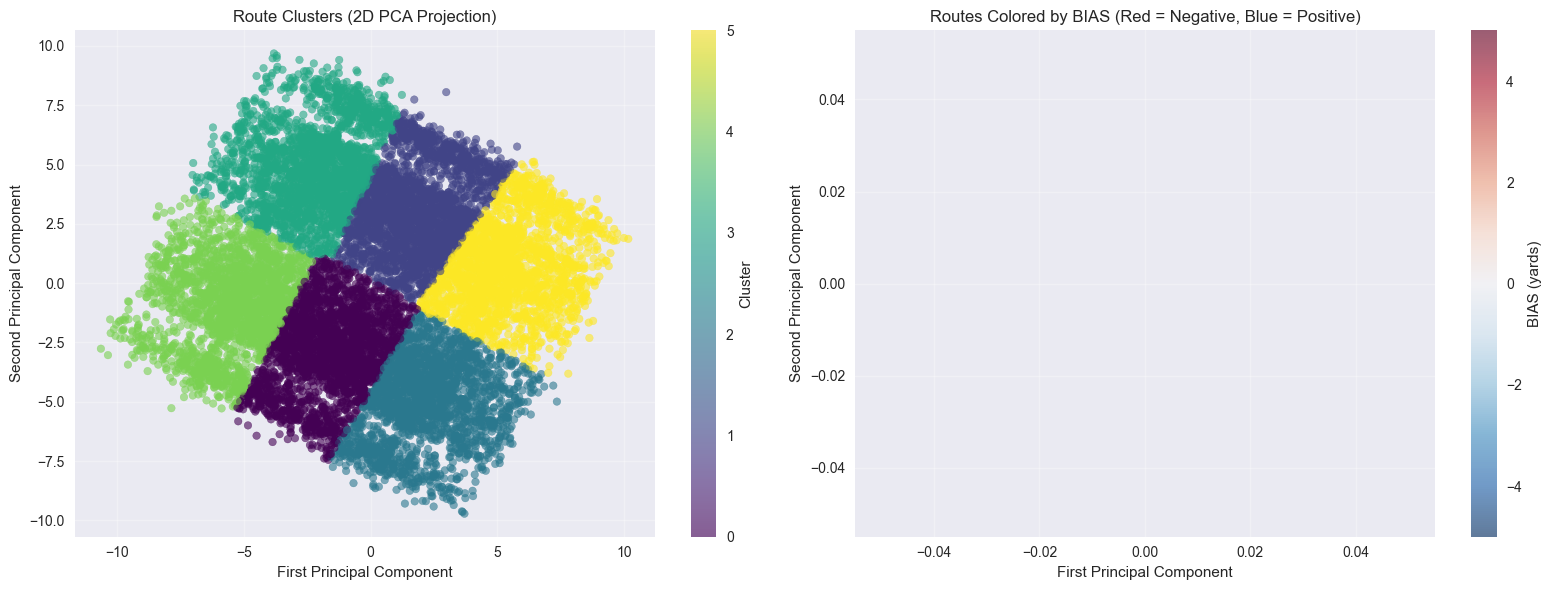


📊 Cluster Profiles (Average Metrics):
 cluster  mean_bias  std_bias  n_plays  def_success_rate
       0        NaN       NaN        0               0.0
       1        NaN       NaN        0               0.0
       2        NaN       NaN        0               0.0
       3        NaN       NaN        0               0.0
       4        NaN       NaN        0               0.0
       5        NaN       NaN        0               0.0


In [40]:
# =========================
# Cell 26 — Visualize Route Clusters (2D PCA Projection)
# =========================
if len(route_vectors) > 0 and 'cluster' in route_vectors.columns:
    # 2D PCA for visualization
    pca_2d = PCA(n_components=2, random_state=42)
    feature_cols = [c for c in route_vectors.columns if c.startswith('x_') or c.startswith('y_')]
    features_2d = route_vectors[feature_cols].fillna(0).values
    
    # Use scaler from Cell 25 if available, otherwise create a new one
    if 'scaler' in locals():
        features_2d_scaled = scaler.transform(features_2d)
    else:
        from sklearn.preprocessing import StandardScaler
        scaler_2d = StandardScaler()
        features_2d_scaled = scaler_2d.fit_transform(features_2d)
    
    proj_2d = pca_2d.fit_transform(features_2d_scaled)
    
    # Create visualization dataframe
    viz_df = pd.DataFrame(proj_2d, columns=['PC1', 'PC2'])
    viz_df['cluster'] = route_vectors['cluster'].values
    viz_df['bias'] = route_vectors['bias'].values
    viz_df['defensive_success'] = route_vectors['defensive_success'].values
    viz_df['target_name'] = route_vectors['target_name'].values
    
    # Plot clusters
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Clusters colored by cluster ID
    ax = axes[0]
    scatter = ax.scatter(viz_df['PC1'], viz_df['PC2'], c=viz_df['cluster'], 
                        cmap='viridis', alpha=0.6, s=30)
    ax.set_xlabel('First Principal Component')
    ax.set_ylabel('Second Principal Component')
    ax.set_title('Route Clusters (2D PCA Projection)')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Cluster')
    
    # Plot 2: Colored by BIAS
    ax = axes[1]
    scatter = ax.scatter(viz_df['PC1'], viz_df['PC2'], c=viz_df['bias'], 
                        cmap='RdBu_r', alpha=0.6, s=30, vmin=-5, vmax=5)
    ax.set_xlabel('First Principal Component')
    ax.set_ylabel('Second Principal Component')
    ax.set_title('Routes Colored by BIAS (Red = Negative, Blue = Positive)')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='BIAS (yards)')
    
    plt.tight_layout()
    plt.show()
    
    # Cluster profiles
    print("\n📊 Cluster Profiles (Average Metrics):")
    cluster_profiles = route_vectors.groupby('cluster').agg({
        'bias': ['mean', 'std', 'count'],
        'defensive_success': 'mean',
    }).reset_index()
    cluster_profiles.columns = ['cluster', 'mean_bias', 'std_bias', 'n_plays', 'def_success_rate']
    cluster_profiles['def_success_rate'] = cluster_profiles['def_success_rate'] * 100
    print(cluster_profiles.to_string(index=False))
else:
    print("⚠️  No route vectors to visualize")


🎯 Visualizing Standout Play:
   Game ID: 2023120309
   Play ID: 4090
   BIAS: -9.16 yards
   Defender: Ambry Thomas


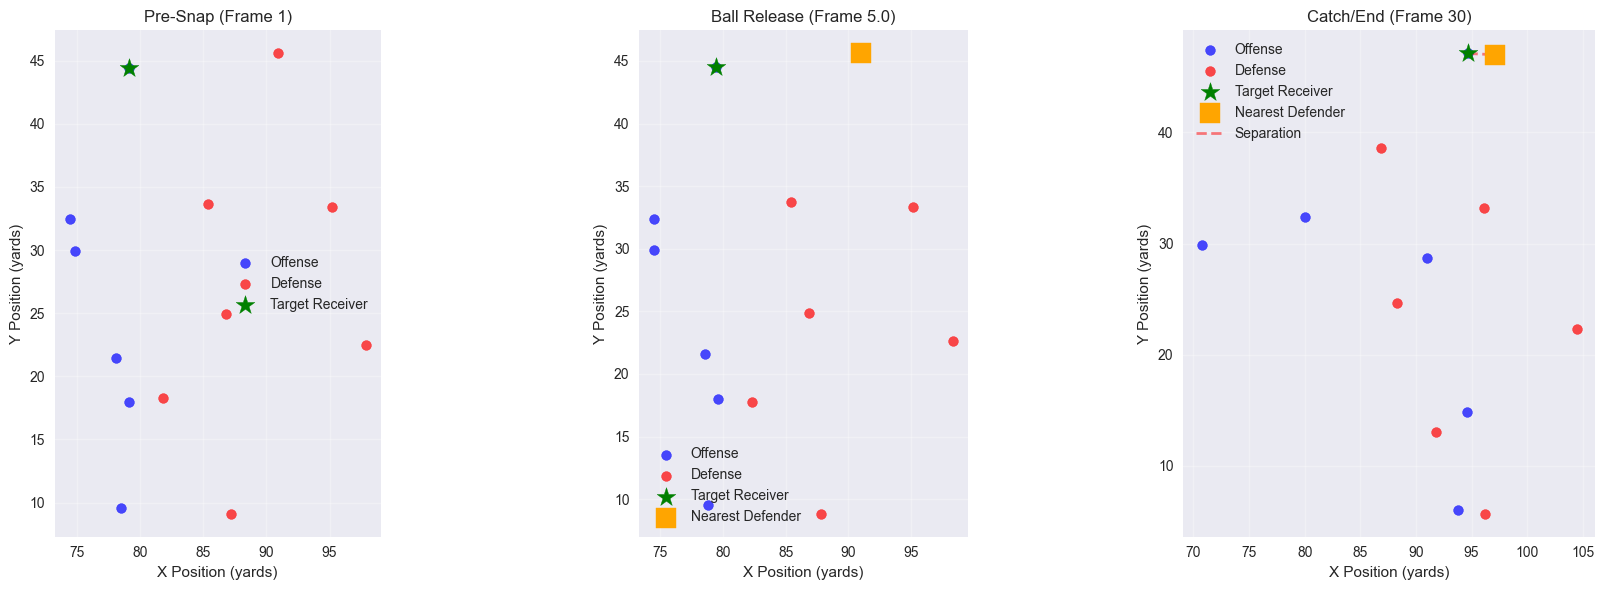


✅ Visualization complete for play 4090


In [41]:
# =========================
# Cell 27 — Visualize Standout Play: Field Plot
# =========================
# Pick a standout play with extreme negative BIAS to visualize
if 'standout_plays' not in locals() or len(standout_plays) == 0:
    print("⚠️  standout_plays not available. Run Cell 23 first.")
elif 'tracking' not in locals():
    print("⚠️  tracking data not available. Run earlier cells first.")
elif len(standout_plays) > 0:
    # Get the play with most negative BIAS
    standout_play_id = standout_plays['play_id'].iloc[0]
    standout_game_id = standout_plays['game_id'].iloc[0]
    
    print(f"🎯 Visualizing Standout Play:")
    print(f"   Game ID: {standout_game_id}")
    print(f"   Play ID: {standout_play_id}")
    print(f"   BIAS: {standout_plays.iloc[0]['bias']:.2f} yards")
    print(f"   Defender: {standout_plays.iloc[0].get('nearest_defender_name', 'N/A')}")
    
    # Get tracking data for this play
    play_tracking = tracking[
        (tracking['game_id'] == standout_game_id) & 
        (tracking['play_id'] == standout_play_id)
    ].copy()
    
    if len(play_tracking) > 0:
        # Get snap frame and ball release frame
        snap_frame = play_tracking['frame_id'].min()
        ball_release_frame = play_tracking['ball_release_frame'].iloc[0]
        catch_frame = play_tracking['frame_id'].max()
        
        # Get target receiver and nearest defender
        target_nfl_id = standout_plays.iloc[0]['target_nfl_id']
        target_data = play_tracking[play_tracking['nfl_id'] == target_nfl_id].sort_values('frame_id')
        
        # Find nearest defender at release
        release_frame_data = play_tracking[play_tracking['frame_id'] == ball_release_frame]
        target_at_release = release_frame_data[release_frame_data['nfl_id'] == target_nfl_id]
        if len(target_at_release) > 0:
            target_x_rel = target_at_release['x'].iloc[0]
            target_y_rel = target_at_release['y'].iloc[0]
            
            defenders_at_release = release_frame_data[
                (release_frame_data['player_side'] == 'Defense') &
                (release_frame_data['player_position'].isin(['CB', 'LB', 'FS', 'SS']))
            ]
            if len(defenders_at_release) > 0:
                defenders_at_release = defenders_at_release.copy()
                defenders_at_release['dist'] = np.sqrt(
                    (defenders_at_release['x'] - target_x_rel)**2 + 
                    (defenders_at_release['y'] - target_y_rel)**2
                )
                nearest_defender_id = defenders_at_release.loc[defenders_at_release['dist'].idxmin(), 'nfl_id']
                defender_data = play_tracking[play_tracking['nfl_id'] == nearest_defender_id].sort_values('frame_id')
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # Plot 1: Pre-snap (snap frame)
        ax = axes[0]
        snap_data = play_tracking[play_tracking['frame_id'] == snap_frame]
        offense = snap_data[snap_data['player_side'] == 'Offense']
        defense = snap_data[snap_data['player_side'] == 'Defense']
        
        ax.scatter(offense['x'], offense['y'], c='blue', s=50, alpha=0.7, label='Offense')
        ax.scatter(defense['x'], defense['y'], c='red', s=50, alpha=0.7, label='Defense')
        if len(target_data) > 0:
            target_snap = target_data[target_data['frame_id'] == snap_frame]
            if len(target_snap) > 0:
                ax.scatter(target_snap['x'], target_snap['y'], c='green', s=200, marker='*', 
                          label='Target Receiver', zorder=5)
        ax.set_xlabel('X Position (yards)')
        ax.set_ylabel('Y Position (yards)')
        ax.set_title(f'Pre-Snap (Frame {snap_frame})')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        
        # Plot 2: Ball Release
        ax = axes[1]
        release_data = play_tracking[play_tracking['frame_id'] == ball_release_frame]
        offense_rel = release_data[release_data['player_side'] == 'Offense']
        defense_rel = release_data[release_data['player_side'] == 'Defense']
        
        ax.scatter(offense_rel['x'], offense_rel['y'], c='blue', s=50, alpha=0.7, label='Offense')
        ax.scatter(defense_rel['x'], defense_rel['y'], c='red', s=50, alpha=0.7, label='Defense')
        if len(target_data) > 0:
            target_rel = target_data[target_data['frame_id'] == ball_release_frame]
            if len(target_rel) > 0:
                ax.scatter(target_rel['x'], target_rel['y'], c='green', s=200, marker='*', 
                          label='Target Receiver', zorder=5)
        if 'defender_data' in locals() and len(defender_data) > 0:
            def_rel = defender_data[defender_data['frame_id'] == ball_release_frame]
            if len(def_rel) > 0:
                ax.scatter(def_rel['x'], def_rel['y'], c='orange', s=200, marker='s', 
                          label='Nearest Defender', zorder=5)
        ax.set_xlabel('X Position (yards)')
        ax.set_ylabel('Y Position (yards)')
        ax.set_title(f'Ball Release (Frame {ball_release_frame})')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        
        # Plot 3: Catch/End of Input
        ax = axes[2]
        catch_data = play_tracking[play_tracking['frame_id'] == catch_frame]
        offense_catch = catch_data[catch_data['player_side'] == 'Offense']
        defense_catch = catch_data[catch_data['player_side'] == 'Defense']
        
        ax.scatter(offense_catch['x'], offense_catch['y'], c='blue', s=50, alpha=0.7, label='Offense')
        ax.scatter(defense_catch['x'], defense_catch['y'], c='red', s=50, alpha=0.7, label='Defense')
        if len(target_data) > 0:
            target_catch = target_data[target_data['frame_id'] == catch_frame]
            if len(target_catch) > 0:
                ax.scatter(target_catch['x'], target_catch['y'], c='green', s=200, marker='*', 
                          label='Target Receiver', zorder=5)
        if 'defender_data' in locals() and len(defender_data) > 0:
            def_catch = defender_data[defender_data['frame_id'] == catch_frame]
            if len(def_catch) > 0:
                ax.scatter(def_catch['x'], def_catch['y'], c='orange', s=200, marker='s', 
                          label='Nearest Defender', zorder=5)
                # Draw line showing separation change
                if len(target_catch) > 0:
                    ax.plot([target_catch['x'].iloc[0], def_catch['x'].iloc[0]], 
                           [target_catch['y'].iloc[0], def_catch['y'].iloc[0]], 
                           'r--', linewidth=2, alpha=0.5, label='Separation')
        ax.set_xlabel('X Position (yards)')
        ax.set_ylabel('Y Position (yards)')
        ax.set_title(f'Catch/End (Frame {catch_frame})')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n✅ Visualization complete for play {standout_play_id}")
    else:
        print(f"⚠️  Could not find tracking data for play {standout_play_id}")
else:
    print("⚠️  No standout plays to visualize")



✅ Animation displayed for play 4090

💾 To save as GIF, use:
   from matplotlib.animation import PillowWriter
   anim.save('play_4090_animation.gif', writer=PillowWriter(fps=10))


/Users/mightenyip/Documents/GitHub/nfl-big-data-bowl-2026-hawk/venv/lib/python3.13/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


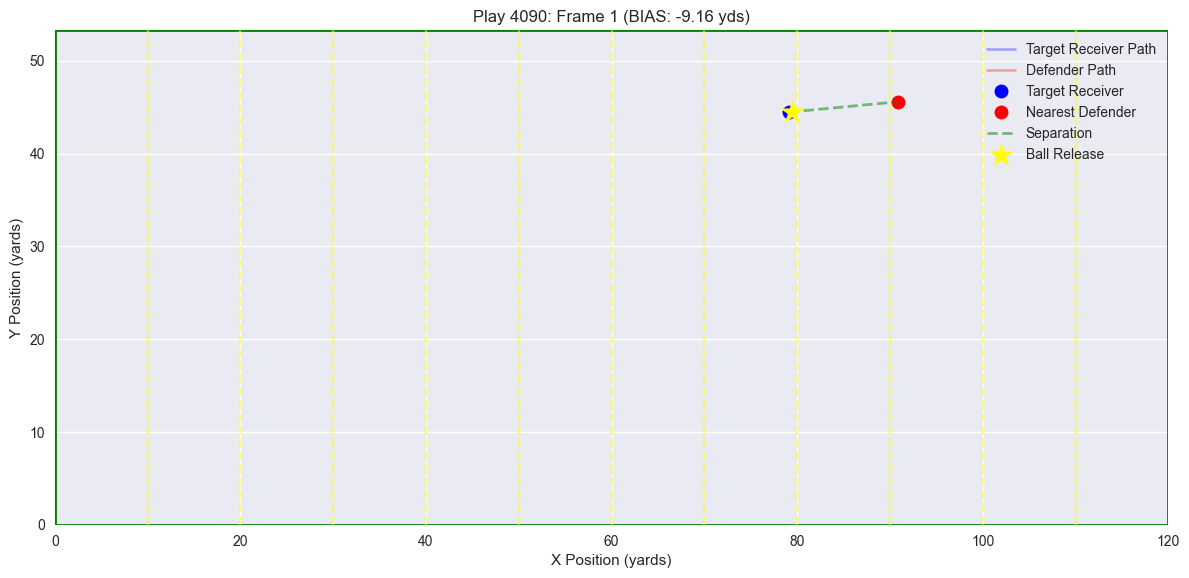

In [48]:
# =========================
# Cell 28 — Animated Visualization: Player Movement Over Time
# =========================
# Create an animated GIF showing player movement throughout the play
import matplotlib.animation as animation
from matplotlib.patches import Rectangle, Circle
from IPython.display import HTML, display

if 'standout_plays' not in locals() or len(standout_plays) == 0:
    print("⚠️  standout_plays not available. Run Cell 23 first.")
elif len(standout_plays) > 0:
    standout_play_id = standout_plays['play_id'].iloc[0]
    standout_game_id = standout_plays['game_id'].iloc[0]
    
    # Get tracking data for this play
    if 'tracking' in locals():
        play_tracking = tracking[
            (tracking['game_id'] == standout_game_id) & 
            (tracking['play_id'] == standout_play_id)
        ].copy()
    else:
        print("⚠️  tracking data not available. Run earlier cells first.")
        play_tracking = pd.DataFrame()
    
    if len(play_tracking) > 0:
        # Get frames
        frames = sorted(play_tracking['frame_id'].unique())
        snap_frame = frames[0]
        ball_release_frame = play_tracking['ball_release_frame'].iloc[0]
        
        # Get target and defender
        target_nfl_id = standout_plays.iloc[0]['target_nfl_id']
        target_traj = play_tracking[play_tracking['nfl_id'] == target_nfl_id].sort_values('frame_id')
        
        # Find nearest defender trajectory
        if len(target_traj) > 0:
            # Get defender at each frame
            defender_traj = []
            for frame_id in frames:
                frame_data = play_tracking[play_tracking['frame_id'] == frame_id]
                target_frame = frame_data[frame_data['nfl_id'] == target_nfl_id]
                if len(target_frame) > 0:
                    target_x = target_frame['x'].iloc[0]
                    target_y = target_frame['y'].iloc[0]
                    
                    defenders_frame = frame_data[
                        (frame_data['player_side'] == 'Defense') &
                        (frame_data['player_position'].isin(['CB', 'LB', 'FS', 'SS']))
                    ]
                    if len(defenders_frame) > 0:
                        defenders_frame = defenders_frame.copy()
                        defenders_frame['dist'] = np.sqrt(
                            (defenders_frame['x'] - target_x)**2 + 
                            (defenders_frame['y'] - target_y)**2
                        )
                        nearest = defenders_frame.loc[defenders_frame['dist'].idxmin()]
                        defender_traj.append({
                            'frame_id': frame_id,
                            'x': nearest['x'],
                            'y': nearest['y'],
                            'nfl_id': nearest['nfl_id'],
                            'name': nearest['player_name']
                        })
            
            defender_traj_df = pd.DataFrame(defender_traj)
            
            # Create animation
            fig, ax = plt.subplots(figsize=(12, 6))
            
            # Draw field
            ax.add_patch(Rectangle((0, 0), 120, 53.3, fill=False, edgecolor='green', linewidth=2))
            ax.axvline(10, color='yellow', linestyle='--', alpha=0.5)
            ax.axvline(20, color='yellow', linestyle='--', alpha=0.5)
            ax.axvline(30, color='yellow', linestyle='--', alpha=0.5)
            ax.axvline(40, color='yellow', linestyle='--', alpha=0.5)
            ax.axvline(50, color='yellow', linestyle='--', alpha=0.5)
            ax.axvline(60, color='yellow', linestyle='--', alpha=0.5)
            ax.axvline(70, color='yellow', linestyle='--', alpha=0.5)
            ax.axvline(80, color='yellow', linestyle='--', alpha=0.5)
            ax.axvline(90, color='yellow', linestyle='--', alpha=0.5)
            ax.axvline(100, color='yellow', linestyle='--', alpha=0.5)
            ax.axvline(110, color='yellow', linestyle='--', alpha=0.5)
            
            ax.set_xlim(0, 120)
            ax.set_ylim(0, 53.3)
            ax.set_xlabel('X Position (yards)')
            ax.set_ylabel('Y Position (yards)')
            ax.set_aspect('equal')
            ax.set_title(f'Play {standout_play_id}: Target Receiver vs Nearest Defender Movement')
            
            # Initialize trajectory lines
            target_line, = ax.plot([], [], 'b-', linewidth=2, alpha=0.3, label='Target Receiver Path')
            defender_line, = ax.plot([], [], 'r-', linewidth=2, alpha=0.3, label='Defender Path')
            target_point, = ax.plot([], [], 'bo', markersize=10, label='Target Receiver')
            defender_point, = ax.plot([], [], 'ro', markersize=10, label='Nearest Defender')
            separation_line, = ax.plot([], [], 'g--', linewidth=2, alpha=0.5, label='Separation')
            
            # Ball release marker
            release_marker = None
            
            def animate(frame_idx):
                if frame_idx >= len(frames):
                    return target_line, defender_line, target_point, defender_point, separation_line
                
                frame_id = frames[frame_idx]
                frame_data = play_tracking[play_tracking['frame_id'] == frame_id]
                
                # Update target trajectory
                target_frames = target_traj[target_traj['frame_id'] <= frame_id]
                if len(target_frames) > 0:
                    target_line.set_data(target_frames['x'], target_frames['y'])
                    target_point.set_data([target_frames['x'].iloc[-1]], [target_frames['y'].iloc[-1]])
                
                # Update defender trajectory
                defender_frames = defender_traj_df[defender_traj_df['frame_id'] <= frame_id]
                if len(defender_frames) > 0:
                    defender_line.set_data(defender_frames['x'], defender_frames['y'])
                    defender_point.set_data([defender_frames['x'].iloc[-1]], [defender_frames['y'].iloc[-1]])
                    
                    # Draw separation line
                    if len(target_frames) > 0:
                        separation_line.set_data(
                            [target_frames['x'].iloc[-1], defender_frames['x'].iloc[-1]],
                            [target_frames['y'].iloc[-1], defender_frames['y'].iloc[-1]]
                        )
                
                # Mark ball release
                global release_marker
                if frame_id == ball_release_frame and release_marker is None:
                    if len(target_frames) > 0:
                        release_marker = ax.scatter([target_frames['x'].iloc[-1]], 
                                                   [target_frames['y'].iloc[-1]], 
                                                   c='yellow', s=300, marker='*', 
                                                   zorder=10, label='Ball Release')
                
                ax.set_title(f'Play {standout_play_id}: Frame {frame_id} (BIAS: {standout_plays.iloc[0]["bias"]:.2f} yds)')
                ax.legend(loc='upper right')
                
                return target_line, defender_line, target_point, defender_point, separation_line
            
            # Create animation
            anim = animation.FuncAnimation(fig, animate, frames=len(frames), 
                                         interval=100, blit=False, repeat=True)
            
            plt.tight_layout()
            
            # Display animation inline in notebook
            try:
                # Try to display as JavaScript HTML (works in Jupyter notebooks, no ffmpeg needed)
                html_js = HTML(anim.to_jshtml())
                display(html_js)
                print(f"\n✅ Animation displayed for play {standout_play_id}")
            except Exception as e:
                # Fallback to HTML5 video if available
                try:
                    html_video = HTML(anim.to_html5_video())
                    display(html_video)
                    print(f"\n✅ Animation displayed for play {standout_play_id} (HTML5 video)")
                except Exception as e2:
                    # Final fallback to regular display
                    plt.show()
                    print(f"\n✅ Animation created for play {standout_play_id} (displayed as static plot)")
                    print(f"   Note: Animation display failed. Try installing ffmpeg or use plt.show()")
            
            print(f"\n💾 To save as GIF, use:")
            print(f"   from matplotlib.animation import PillowWriter")
            print(f"   anim.save('play_{standout_play_id}_animation.gif', writer=PillowWriter(fps=10))")
            
            # Store animation for potential saving
            globals()['play_animation'] = anim
        else:
            print("⚠️  Could not find target receiver trajectory")
    else:
        print("⚠️  Could not find tracking data")
else:
    print("⚠️  No standout plays available for animation")


TOP DEFENDERS SUMMARY

🏆 Top 10 Defenders by Mean Negative BIAS:

142. Xavier McKinney (Unknown)
   Mean BIAS: -4.917 yards
   Plays with negative BIAS: 3
   Best play: -6.605 yards
   Most common coverage: COVER_3_ZONE
   Avg separation at release: 6.92 yds
   Avg separation at catch: 2.00 yds

272. Clark Phillips III (Unknown)
   Mean BIAS: -3.804 yards
   Plays with negative BIAS: 4
   Best play: -5.528 yards
   Most common coverage: COVER_1_MAN
   Avg separation at release: 5.90 yds
   Avg separation at catch: 2.09 yds

26. Artie Burns (Unknown)
   Mean BIAS: -3.713 yards
   Plays with negative BIAS: 3
   Best play: -5.222 yards
   Most common coverage: COVER_1_MAN
   Avg separation at release: 5.61 yds
   Avg separation at catch: 1.89 yds

151. Julian Blackmon (Unknown)
   Mean BIAS: -3.239 yards
   Plays with negative BIAS: 6
   Best play: -5.663 yards
   Most common coverage: COVER_3_ZONE
   Avg separation at release: 5.87 yds
   Avg separation at catch: 2.63 yds

196. Talanoa H

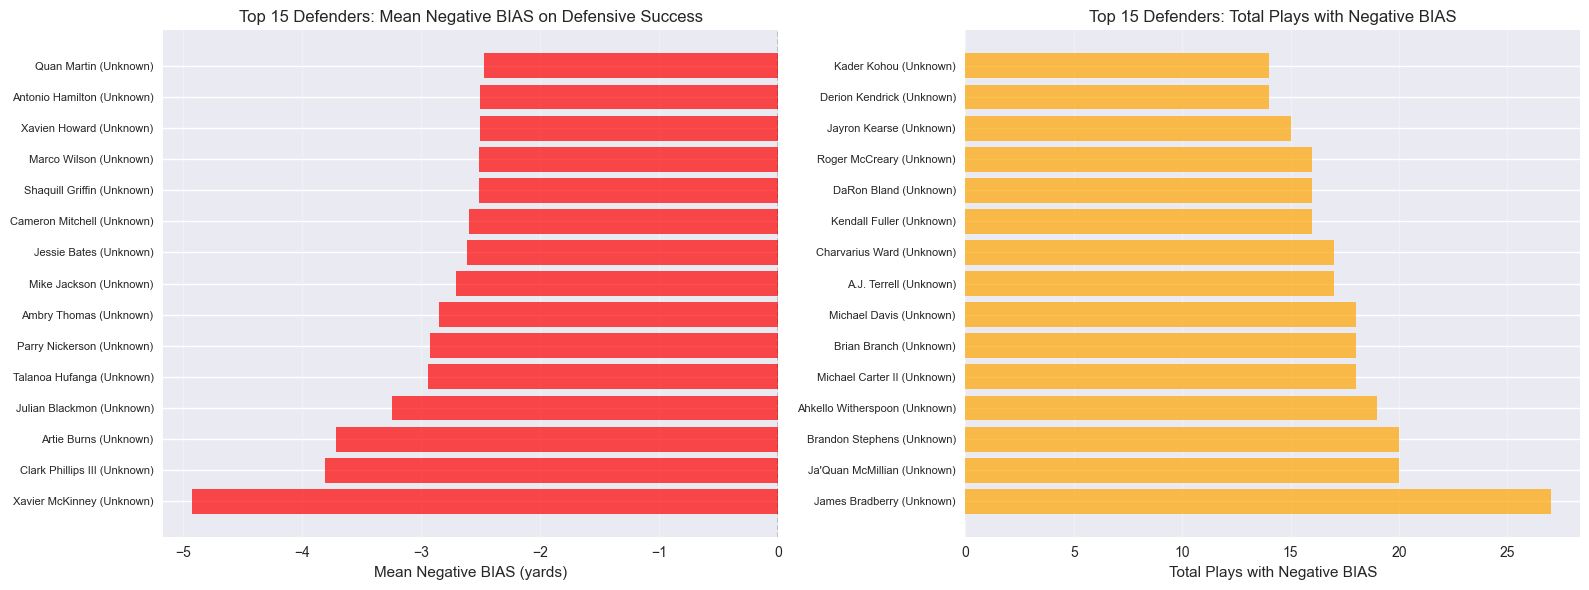

In [49]:
# =========================
# Cell 29 — Top Players Summary Table
# =========================
# Create a comprehensive summary of top players with negative BIAS

if 'defender_stats' not in locals() or len(defender_stats) == 0:
    print("⚠️  defender_stats not available. Run Cell 22 first.")
elif len(defender_stats) > 0:
    print("=" * 80)
    print("TOP DEFENDERS SUMMARY")
    print("=" * 80)
    
    # Get coverage and depth breakdown for top defenders
    print("\n🏆 Top 10 Defenders by Mean Negative BIAS:")
    for idx, row in defender_stats.head(10).iterrows():
        # Try to get defender plays from bias_full if available
        defender_plays = pd.DataFrame()
        if 'bias_full' in locals() and 'nearest_defender_nfl_id' in bias_full.columns:
            defender_plays = bias_full[
                (bias_full['nearest_defender_nfl_id'] == row['nfl_id']) & 
                (bias_full['defensive_success'] == 1) &
                (bias_full['bias'] < 0)
            ]
        elif 'defender_bias' in locals():
            # Use defender_bias from Cell 22 if available
            defender_plays = defender_bias[
                (defender_bias['nearest_defender_nfl_id'] == row['nfl_id']) &
                (defender_bias['bias'] < 0)
            ]
        
        print(f"\n{idx+1}. {row['defender_name']} ({row['position']})")
        print(f"   Mean BIAS: {row['mean_bias']:.3f} yards")
        print(f"   Plays with negative BIAS: {row['n_plays']}")
        print(f"   Best play: {row['min_bias']:.3f} yards")
        if len(defender_plays) > 0 and 'team_coverage_type' in defender_plays.columns:
            coverage_mode = defender_plays['team_coverage_type'].mode()
            if len(coverage_mode) > 0:
                print(f"   Most common coverage: {coverage_mode.iloc[0]}")
        if 'avg_sep_release' in row:
            print(f"   Avg separation at release: {row['avg_sep_release']:.2f} yds")
        if 'avg_sep_catch' in row:
            print(f"   Avg separation at catch: {row['avg_sep_catch']:.2f} yds")
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top 15 defenders by mean negative BIAS
    top_15 = defender_stats.head(15)
    ax = axes[0]
    ax.barh(range(len(top_15)), top_15['mean_bias'], color='red', alpha=0.7)
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels([f"{row['defender_name'][:20]} ({row['position']})" 
                        for _, row in top_15.iterrows()], fontsize=8)
    ax.set_xlabel('Mean Negative BIAS (yards)')
    ax.set_title('Top 15 Defenders: Mean Negative BIAS on Defensive Success')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.grid(True, alpha=0.3, axis='x')
    
    # Top 15 by total plays
    if 'defender_total' in locals() and len(defender_total) > 0:
        top_15_total = defender_total.head(15)
        ax = axes[1]
        ax.barh(range(len(top_15_total)), top_15_total['total_negative_bias_plays'], color='orange', alpha=0.7)
        ax.set_yticks(range(len(top_15_total)))
        ax.set_yticklabels([f"{row['defender_name'][:20]} ({row['position']})" 
                            for _, row in top_15_total.iterrows()], fontsize=8)
        ax.set_xlabel('Total Plays with Negative BIAS')
        ax.set_title('Top 15 Defenders: Total Plays with Negative BIAS')
        ax.grid(True, alpha=0.3, axis='x')
    else:
        # Hide second subplot if defender_total not available
        axes[1].axis('off')
        axes[1].text(0.5, 0.5, 'defender_total not available', 
                     ha='center', va='center', transform=axes[1].transAxes)
    
    plt.tight_layout()
    plt.show()
